In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/age_pred_output_2025-10-10 14:37:35.506749_ContrastiveLoss_gru_catboost/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

5640

In [4]:
print(df_all)

      batch_size  learning_rate  split_count  cnt_min  cnt_max  embedding_dim  \
0             16          0.001            3       10      100             16   
1             16          0.001            3       10      100             16   
2             16          0.001            3       10      100             16   
3             16          0.001            3       10      100             16   
4             16          0.001            3       10      100             16   
...          ...            ...          ...      ...      ...            ...   
5635         128          0.001            3       10      100             16   
5636         128          0.001            3       10      100             16   
5637         128          0.001            3       10      100             16   
5638         128          0.001            3       10      100             16   
5639         128          0.001            3       10      100             16   

      category_embedding_di

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [8]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['recall_topk']

In [9]:
print(metric_columns)

['metric_rankme', 'metric_coherence', 'metric_pseudo_condition_number', 'metric_alpha_req', 'metric_stable_rank', 'metric_ne_sum', 'metric_self_clustering', 'metric_ripser_sum_H0', 'metric_ripser_sq_sum_H0', 'metric_ripser_sum_H0_norm0.5', 'metric_ripser_sq_sum_H0_norm0.5', 'metric_ripser_sum_H0_norm0.7', 'metric_ripser_sq_sum_H0_norm0.7', 'metric_ripser_sum_H0_norm0.8', 'metric_ripser_sq_sum_H0_norm0.8', 'metric_ripser_sum_H0_norm0.9', 'metric_ripser_sq_sum_H0_norm0.9', 'metric_ripser_sum_H0_norm0.95', 'metric_ripser_sq_sum_H0_norm0.95', 'metric_ripser_sum_H0_norm0.99', 'metric_ripser_sq_sum_H0_norm0.99', 'metric_ripser_sum_H1', 'metric_ripser_sq_sum_H1', 'metric_ripser_sum_H1_norm0.5', 'metric_ripser_sq_sum_H1_norm0.5', 'metric_ripser_sum_H1_norm0.7', 'metric_ripser_sq_sum_H1_norm0.7', 'metric_ripser_sum_H1_norm0.8', 'metric_ripser_sq_sum_H1_norm0.8', 'metric_ripser_sum_H1_norm0.9', 'metric_ripser_sq_sum_H1_norm0.9', 'metric_ripser_sum_H1_norm0.95', 'metric_ripser_sq_sum_H1_norm0.95'

In [7]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

NameError: name 'MinMaxScaler' is not defined

In [10]:
df_all = df_all.set_index('checkpoint')

In [11]:
import numpy as np
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign 
            })

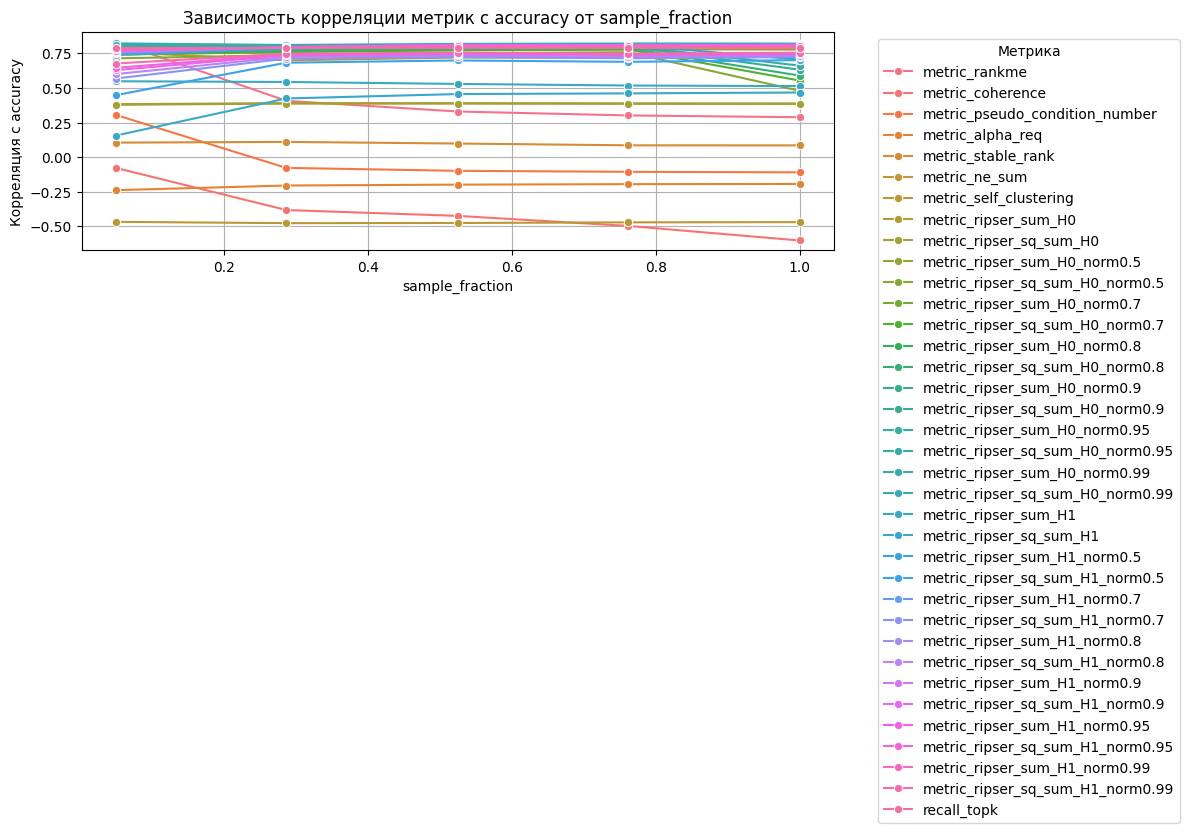

In [12]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [13]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.833446
1               0.05                  metric_coherence    -0.077053
2               0.05    metric_pseudo_condition_number     0.305570
3               0.05                  metric_alpha_req    -0.238160
4               0.05                metric_stable_rank     0.105186
..               ...                               ...          ...
175             1.00     metric_ripser_sum_H1_norm0.95     0.810014
176             1.00  metric_ripser_sq_sum_H1_norm0.95     0.750630
177             1.00     metric_ripser_sum_H1_norm0.99     0.803916
178             1.00  metric_ripser_sq_sum_H1_norm0.99     0.754685
179             1.00                       recall_topk     0.786866

[180 rows x 3 columns]


In [14]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.99       0.818655
metric_ripser_sum_H0_norm0.95       0.810301
metric_ripser_sum_H0_norm0.9        0.803732
metric_ripser_sum_H1_norm0.95       0.798114
metric_ripser_sum_H1_norm0.9        0.797986
metric_ripser_sum_H1_norm0.8        0.796116
metric_ripser_sum_H1_norm0.99       0.795669
metric_ripser_sum_H0_norm0.8        0.793607
metric_ripser_sum_H1_norm0.7        0.793519
metric_ripser_sq_sum_H0_norm0.99    0.787290
recall_topk                         0.786866
metric_ripser_sum_H1_norm0.5        0.786021
metric_ripser_sum_H0_norm0.7        0.784479
metric_ripser_sq_sum_H0_norm0.95    0.769091
metric_ripser_sum_H0_norm0.5        0.766543
metric_ripser_sq_sum_H0_norm0.9     0.756353
metric_ripser_sq_sum_H0_norm0.8     0.737571
metric_ripser_sq_sum_H1_norm0.99    0.736549
metric_ripser_sq_sum_H1_norm0.95    0.727090
metric_ne_sum                       0.724290
metric_ripser_sq_sum_H0_norm0.7     0.721205
metric_ripser_sq_sum_H1_norm0.9     0.718808
met

In [15]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.99       0.820821
metric_ripser_sum_H0_norm0.95       0.814916
metric_ripser_sum_H1_norm0.9        0.811272
metric_ripser_sum_H1_norm0.8        0.811176
metric_ripser_sum_H1_norm0.95       0.810014
metric_ripser_sum_H1_norm0.7        0.810004
metric_ripser_sum_H0_norm0.9        0.809462
metric_ripser_sum_H1_norm0.5        0.805443
metric_ripser_sum_H1_norm0.99       0.803916
metric_ripser_sum_H0_norm0.8        0.800704
metric_ripser_sum_H0_norm0.7        0.792961
recall_topk                         0.786866
metric_ripser_sum_H0_norm0.5        0.777330
metric_ripser_sq_sum_H1_norm0.99    0.754685
metric_ripser_sq_sum_H1_norm0.95    0.750630
metric_ripser_sq_sum_H1_norm0.9     0.744862
metric_ripser_sq_sum_H1_norm0.8     0.734405
metric_ne_sum                       0.724405
metric_ripser_sq_sum_H1_norm0.7     0.724342
metric_ripser_sq_sum_H0_norm0.99    0.704800
metric_ripser_sq_sum_H1_norm0.5     0.701196
metric_ripser_sq_sum_H0_norm0.95    0.661349
met

In [17]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.2].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_rankme                       0.833446
metric_ripser_sum_H0_norm0.99       0.822021
metric_ripser_sq_sum_H0_norm0.99    0.813608
metric_ripser_sum_H0_norm0.95       0.801622
metric_ripser_sum_H0_norm0.9        0.790920
metric_ripser_sq_sum_H0_norm0.95    0.788312
recall_topk                         0.786866
metric_ripser_sum_H1_norm0.99       0.778505
metric_ripser_sum_H0_norm0.8        0.776435
metric_ripser_sq_sum_H0_norm0.9     0.775211
metric_ripser_sum_H1_norm0.95       0.768419
metric_ripser_sum_H1_norm0.9        0.764452
metric_ripser_sum_H0_norm0.7        0.763371
metric_ne_sum                       0.759640
metric_ripser_sum_H1_norm0.8        0.758296
metric_ripser_sq_sum_H0_norm0.8     0.757715
metric_ripser_sum_H1_norm0.7        0.752595
metric_ripser_sq_sum_H0_norm0.7     0.742136
metric_ripser_sum_H0_norm0.5        0.740413
metric_ripser_sum_H1_norm0.5        0.738891
metric_ripser_sq_sum_H0_norm0.5     0.713921
metric_ripser_sq_sum_H1_norm0.99    0.676735
met

# Overall Spearmann Corr

In [18]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign
            })
            


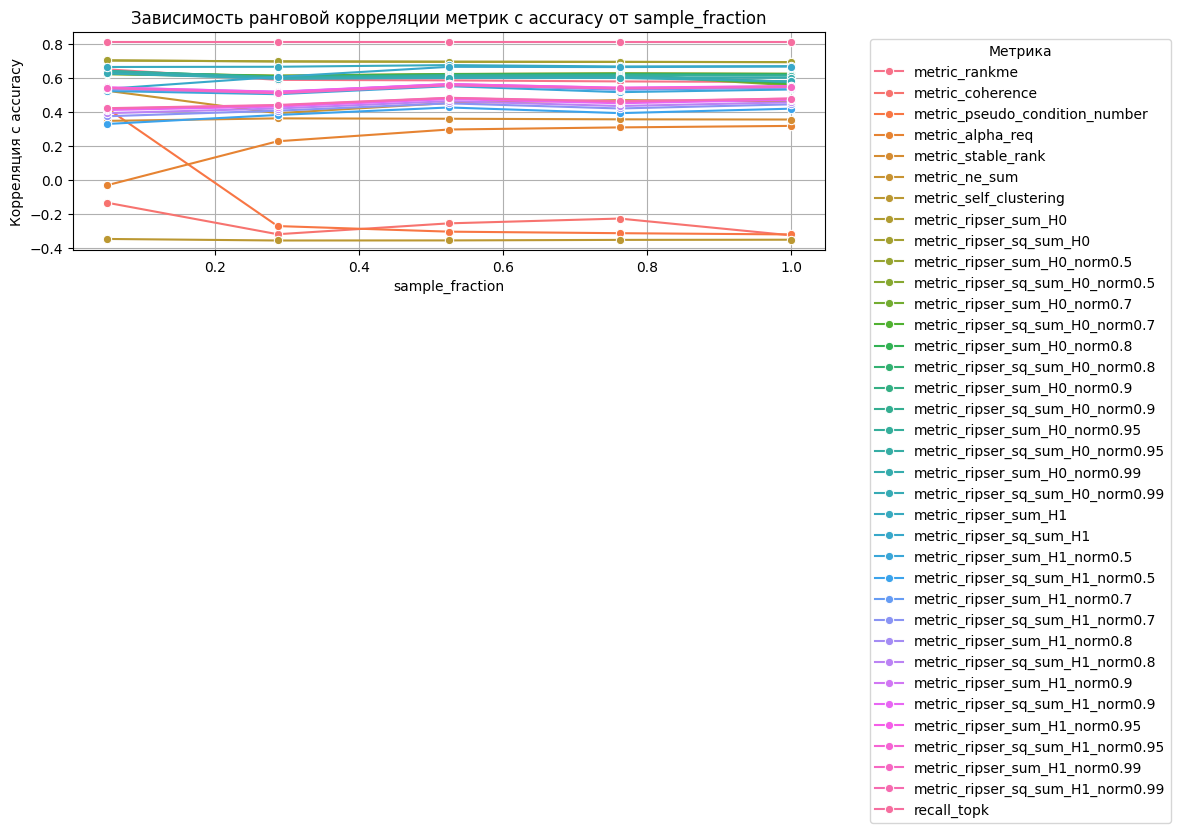

In [19]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [20]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8118637280557034,
 'metric_ripser_sum_H0': 0.6924127391015706,
 'metric_ripser_sq_sum_H0': 0.6922075123279364,
 'metric_ripser_sum_H1': 0.6682953219288448,
 'metric_ripser_sq_sum_H1': 0.6663823468632387,
 'metric_ripser_sum_H0_norm0.5': 0.6236181013413781,
 'metric_ripser_sum_H0_norm0.7': 0.6230807797146112,
 'metric_ripser_sum_H0_norm0.8': 0.6208948392870031,
 'metric_ripser_sum_H0_norm0.9': 0.6167088962047171,
 'metric_ripser_sum_H0_norm0.95': 0.6118600536288047,
 'metric_ripser_sum_H0_norm0.99': 0.5998541849480324,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5787262787145572,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5773510561843062,
 'metric_rankme': 0.5755043681382349,
 'metric_ripser_sq_sum_H0_norm0.9': 0.575475705800024,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5716177960134046,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5641026062927179,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5554674762818872,
 'metric_ripser_sum_H1_norm0.95': 0.5510993033225635,
 'metric_ripser_sum_H1_norm0.

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8118637280557033,
 'metric_ripser_sum_H0': 0.6959466596130801,
 'metric_ripser_sq_sum_H0': 0.6956884856605695,
 'metric_ripser_sum_H1': 0.667667155166861,
 'metric_ripser_sq_sum_H1': 0.6269085624287747,
 'metric_ripser_sum_H0_norm0.5': 0.6226886672266279,
 'metric_ripser_sum_H0_norm0.7': 0.622043067501122,
 'metric_ripser_sum_H0_norm0.8': 0.6216488042292647,
 'metric_ripser_sum_H0_norm0.9': 0.6191581152898058,
 'metric_ripser_sum_H0_norm0.95': 0.616518592245695,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6071340443138816,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6069793372386725,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6061258432502952,
 'metric_ripser_sum_H0_norm0.99': 0.6052599713972069,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6046107923303774,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6022067772485258,
 'metric_ripser_sq_sum_H0_norm0.99': 0.599199288216701,
 'metric_rankme': 0.5953138522923039,
 'metric_ripser_sum_H1_norm0.95': 0.543184005265758,
 'metric_ripser_sum_H1_norm0.9': 

In [24]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8118637280557034,
 'metric_ripser_sum_H0': 0.6995343456012153,
 'metric_ripser_sq_sum_H0': 0.6991792929551759,
 'metric_ripser_sum_H1': 0.6643155169493079,
 'metric_ripser_sum_H0_norm0.8': 0.6222531606692835,
 'metric_ripser_sum_H0_norm0.95': 0.6220099432759469,
 'metric_ripser_sum_H0_norm0.9': 0.6219629794523798,
 'metric_ripser_sum_H0_norm0.5': 0.6203978610115908,
 'metric_ripser_sum_H0_norm0.7': 0.6201054028056237,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6190541373263916,
 'metric_rankme': 0.6188350368767205,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6185894597886732,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6170582408227906,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6143309258679968,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6128199834030883,
 'metric_ripser_sum_H0_norm0.99': 0.6114816901542686,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6099134771346637,
 'metric_ripser_sq_sum_H1': 0.5702510318284182,
 'metric_ripser_sum_H1_norm0.95': 0.5303209298914623,
 'metric_ripser_sum_H1_norm0

# Correlation for best checkpoint choice

In [25]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


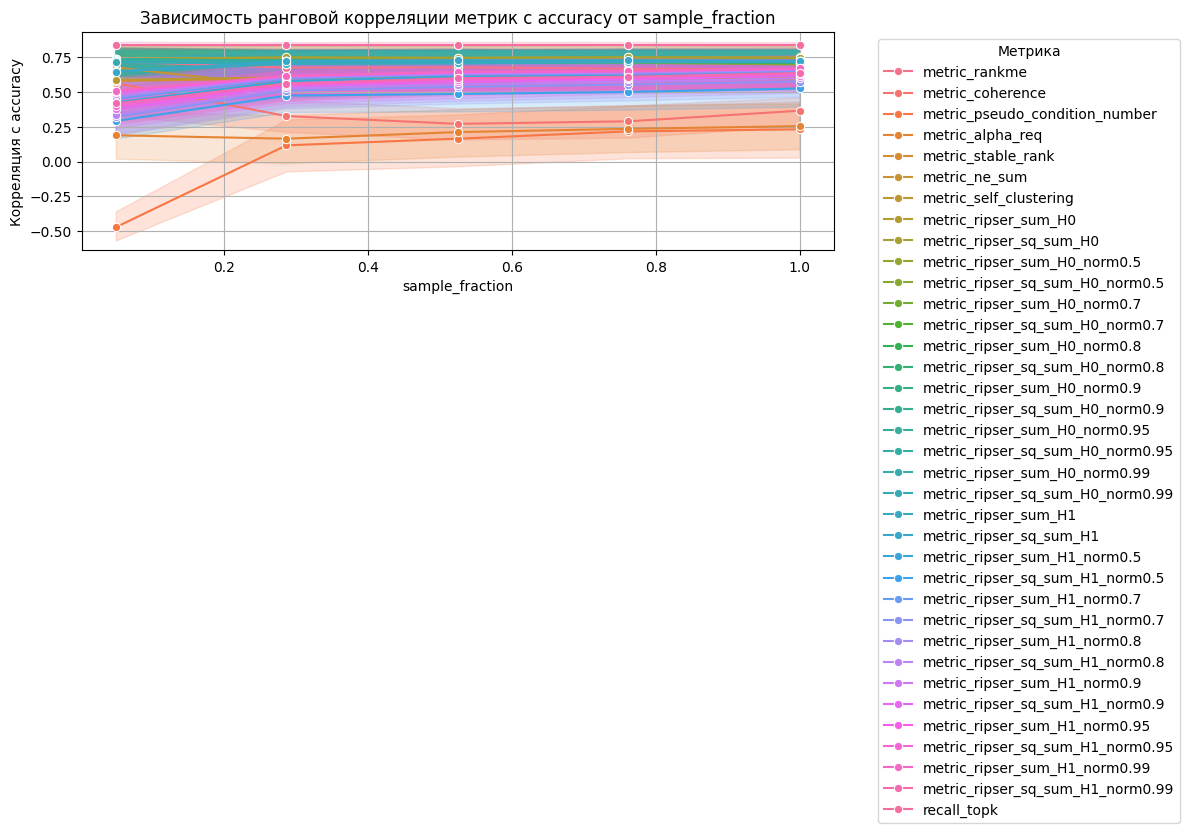

In [26]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [27]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8316816253260089,
 'metric_ripser_sum_H0': 0.7459503007487197,
 'metric_ripser_sq_sum_H0': 0.7406771656362118,
 'metric_ripser_sum_H0_norm0.9': 0.7196654758136648,
 'metric_ripser_sq_sum_H1': 0.7191534441700609,
 'metric_ripser_sum_H0_norm0.95': 0.7190970764657418,
 'metric_ripser_sum_H0_norm0.8': 0.7163978145584422,
 'metric_ripser_sum_H0_norm0.99': 0.7150281298558133,
 'metric_ripser_sum_H1': 0.7149484105814615,
 'metric_ripser_sum_H0_norm0.7': 0.7128409722651626,
 'metric_ripser_sq_sum_H0_norm0.95': 0.711649965286731,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7114607894488695,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7110364828166553,
 'metric_ripser_sum_H0_norm0.5': 0.7068717178504935,
 'metric_ripser_sq_sum_H0_norm0.8': 0.706814790182512,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7035207111618407,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6946906879644686,
 'metric_ripser_sum_H1_norm0.99': 0.667341249541326,
 'metric_ripser_sum_H1_norm0.95': 0.6650882142495117,
 'metric_rankme

In [28]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.831681625326009,
 'metric_ripser_sum_H0': 0.7425623688863203,
 'metric_ripser_sq_sum_H0': 0.7415020522066967,
 'metric_ripser_sum_H0_norm0.95': 0.7230222147844494,
 'metric_ripser_sum_H0_norm0.9': 0.7229810890766768,
 'metric_ripser_sum_H0_norm0.8': 0.7214352539491413,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7184321346727638,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7177299881451104,
 'metric_ripser_sum_H0_norm0.7': 0.7172647834961472,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7143203860012612,
 'metric_ripser_sum_H0_norm0.99': 0.7124247778531656,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7113655407058735,
 'metric_ripser_sum_H0_norm0.5': 0.7092538774162137,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7073169591222798,
 'metric_ripser_sq_sum_H1': 0.7056561564734019,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7049645635935252,
 'metric_ripser_sum_H1': 0.694506302506787,
 'metric_rankme': 0.6769476913570817,
 'metric_ripser_sum_H1_norm0.99': 0.6150420349703583,
 'metric_ripser_sum_H1_norm0.9

In [29]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8316816253260089,
 'metric_ripser_sum_H0': 0.7398499322212969,
 'metric_ripser_sq_sum_H0': 0.7394063286922659,
 'metric_ripser_sum_H0_norm0.95': 0.7273481493019812,
 'metric_ripser_sum_H0_norm0.9': 0.7263153785080291,
 'metric_ripser_sum_H0_norm0.8': 0.7259751787481618,
 'metric_ripser_sum_H0_norm0.7': 0.7220052237022616,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7219154350630667,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7213041197662614,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7187517155592246,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7152360899620467,
 'metric_ripser_sum_H0_norm0.5': 0.7121317688168046,
 'metric_ripser_sum_H0_norm0.99': 0.7110172647097388,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7088960842570592,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7046090079910595,
 'metric_rankme': 0.6936249780075838,
 'metric_ripser_sq_sum_H1': 0.6807996291572747,
 'metric_ripser_sum_H1': 0.6716438701930043,
 'metric_ne_sum': 0.6059701804118739,
 'metric_self_clustering': 0.593604488226898

# Linear correlation of epoch choice

In [30]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

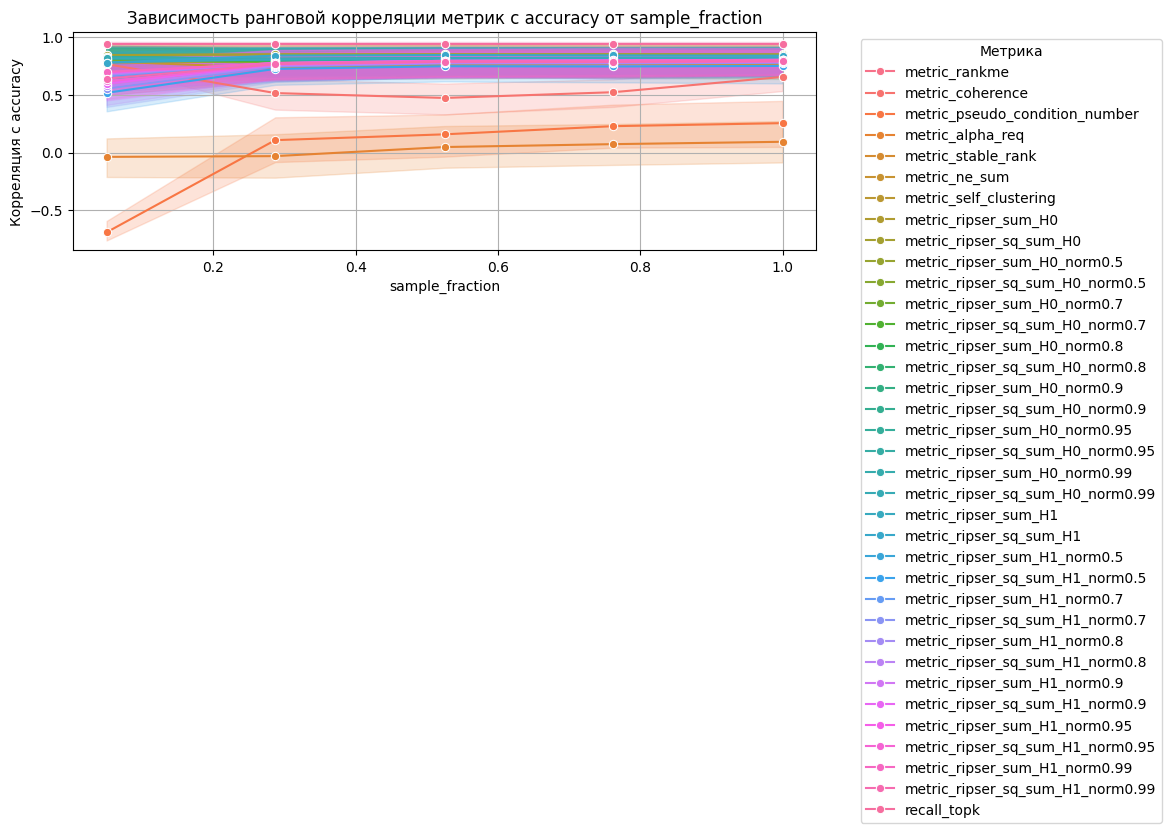

In [31]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.941995
metric_ripser_sum_H0                0.851008
metric_ripser_sq_sum_H0             0.846945
metric_ripser_sq_sum_H1             0.838433
metric_ripser_sq_sum_H0_norm0.99    0.823787
metric_ripser_sum_H1                0.822340
metric_ripser_sum_H0_norm0.99       0.818204
metric_ripser_sq_sum_H0_norm0.95    0.816641
metric_ripser_sum_H0_norm0.95       0.813703
metric_ripser_sq_sum_H0_norm0.9     0.811726
metric_ripser_sum_H0_norm0.9        0.810583
metric_ripser_sum_H0_norm0.8        0.805920
metric_self_clustering              0.805915
metric_ripser_sq_sum_H0_norm0.8     0.804269
metric_ripser_sum_H1_norm0.9        0.802720
metric_ripser_sum_H1_norm0.8        0.802294
metric_ripser_sum_H1_norm0.95       0.802260
metric_ripser_sum_H0_norm0.7        0.801427
metric_ripser_sum_H1_norm0.7        0.801093
metric_ripser_sum_H1_norm0.99       0.799284
metric_ripser_sq_sum_H0_norm0.7     0.797313
metric_ripser_sum_H1_norm0.5        0.796906
met

In [33]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.941995
metric_ripser_sum_H0                0.846985
metric_ripser_sq_sum_H0             0.846171
metric_ripser_sum_H0_norm0.95       0.820687
metric_ripser_sum_H0_norm0.9        0.817819
metric_ripser_sum_H0_norm0.99       0.817523
metric_ripser_sq_sum_H0_norm0.95    0.813345
metric_ripser_sum_H0_norm0.8        0.813143
metric_ripser_sq_sum_H0_norm0.99    0.810731
metric_ripser_sq_sum_H0_norm0.9     0.809871
metric_ripser_sq_sum_H1             0.809004
metric_ripser_sum_H0_norm0.7        0.808693
metric_ripser_sq_sum_H0_norm0.8     0.804200
metric_self_clustering              0.801688
metric_ripser_sq_sum_H0_norm0.7     0.799013
metric_ripser_sum_H0_norm0.5        0.798500
metric_rankme                       0.797332
metric_ripser_sum_H1                0.793460
metric_ripser_sq_sum_H0_norm0.5     0.787477
metric_stable_rank                  0.785647
metric_ne_sum                       0.760024
metric_ripser_sum_H1_norm0.99       0.735807
met

# Score of best epoch

In [34]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

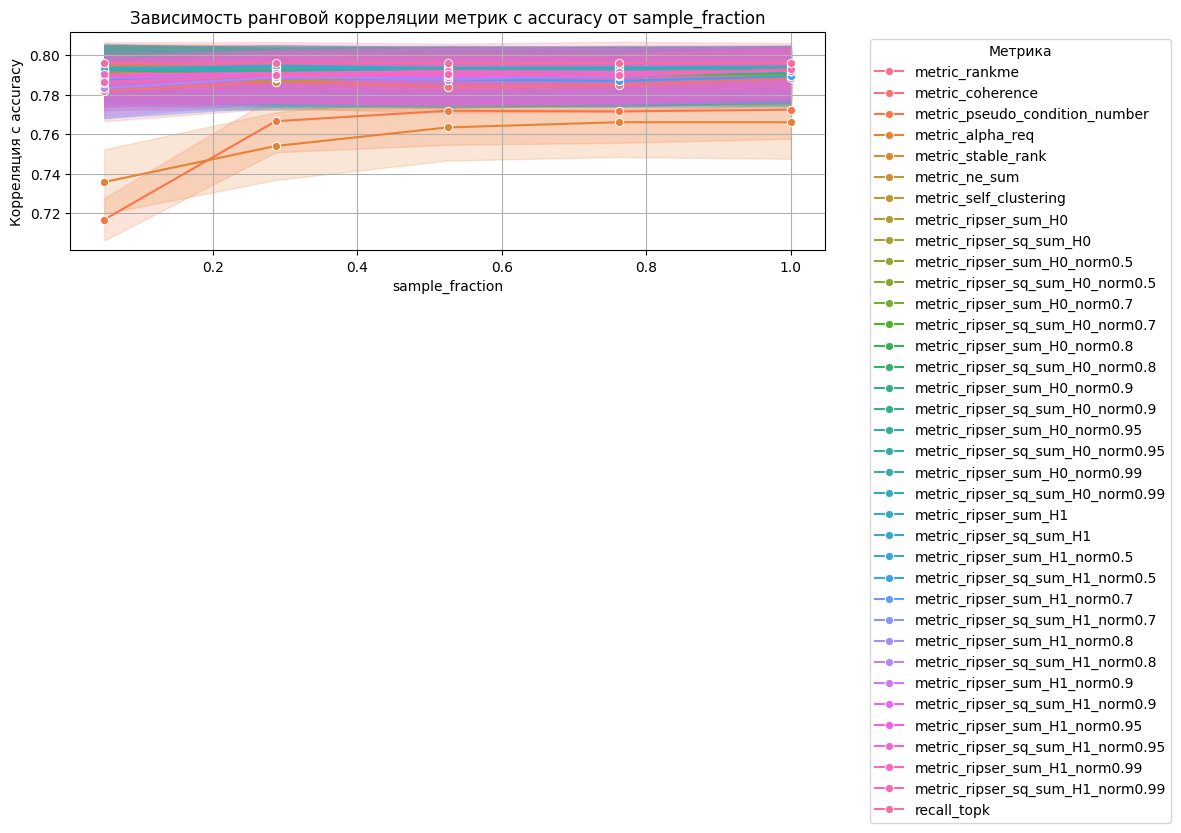

In [35]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [36]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.796423076923077,
 'metric_stable_rank': 0.7939842105263157,
 'metric_ripser_sq_sum_H1': 0.7939564102564102,
 'metric_self_clustering': 0.7936236842105263,
 'metric_ripser_sum_H1': 0.7931897435897436,
 'metric_ripser_sum_H0_norm0.95': 0.7929646153846154,
 'metric_rankme': 0.7928000000000001,
 'metric_ripser_sum_H0_norm0.99': 0.7926969230769231,
 'metric_ripser_sq_sum_H0': 0.7925148717948718,
 'metric_ripser_sum_H0': 0.7924635897435898,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7923210256410257,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7923071794871794,
 'metric_ripser_sum_H0_norm0.9': 0.7921389743589743,
 'metric_ripser_sum_H0_norm0.8': 0.792031282051282,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7917517948717949,
 'metric_ripser_sum_H1_norm0.99': 0.791551282051282,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7914825641025641,
 'metric_ripser_sum_H1_norm0.95': 0.7911035897435897,
 'metric_ripser_sq_sum_H0_norm0.7': 0.791028205128205,
 'metric_ripser_sum_H0_norm0.7': 0.790962564102564

In [37]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7964230769230769,
 'metric_ripser_sq_sum_H1': 0.7943435897435897,
 'metric_stable_rank': 0.7936815789473685,
 'metric_self_clustering': 0.7936815789473685,
 'metric_rankme': 0.7930384615384616,
 'metric_ripser_sq_sum_H1_norm0.99': 0.7928820512820512,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7928717948717949,
 'metric_ripser_sum_H0_norm0.99': 0.7928641025641026,
 'metric_ripser_sum_H1': 0.7928461538461539,
 'metric_ripser_sq_sum_H1_norm0.95': 0.7927307692307692,
 'metric_ripser_sq_sum_H1_norm0.9': 0.7926538461538462,
 'metric_ripser_sum_H0_norm0.95': 0.7926282051282052,
 'metric_ripser_sq_sum_H1_norm0.8': 0.7926,
 'metric_ripser_sq_sum_H0': 0.7925461538461539,
 'metric_ripser_sq_sum_H1_norm0.7': 0.7925076923076924,
 'metric_ripser_sum_H1_norm0.5': 0.7924717948717949,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7924051282051282,
 'metric_ripser_sum_H0': 0.7922435897435898,
 'metric_ripser_sum_H1_norm0.99': 0.7922333333333332,
 'metric_ripser_sum_H1_norm0.8': 0.7922076923076923

In [38]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7964230769230769,
 'metric_stable_rank': 0.7944184210526316,
 'metric_ripser_sum_H1': 0.7939346153846154,
 'metric_ripser_sq_sum_H1': 0.7938794871794872,
 'metric_self_clustering': 0.7935171052631579,
 'metric_ripser_sum_H0_norm0.95': 0.7932230769230769,
 'metric_ripser_sum_H0_norm0.9': 0.7929923076923077,
 'metric_ripser_sum_H0': 0.7927935897435897,
 'metric_ripser_sq_sum_H0': 0.7927871794871795,
 'metric_ripser_sum_H0_norm0.8': 0.7927666666666666,
 'metric_ripser_sum_H0_norm0.99': 0.7927512820512821,
 'metric_rankme': 0.7927448717948717,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7925166666666666,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7923871794871794,
 'metric_ripser_sq_sum_H0_norm0.8': 0.79235,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7922346153846154,
 'metric_ripser_sum_H0_norm0.7': 0.791675641025641,
 'metric_ripser_sq_sum_H0_norm0.7': 0.791524358974359,
 'metric_ripser_sum_H1_norm0.99': 0.7908128205128205,
 'metric_ripser_sum_H0_norm0.5': 0.7906948717948717,
 'metri

In [33]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [34]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme nan
metric_rankme nan
metric_coherence nan
metric_coherence nan
metric_pseudo_condition_number nan
metric_pseudo_condition_number nan
metric_alpha_req nan
metric_alpha_req nan
metric_stable_rank nan
metric_stable_rank nan
metric_ne_sum nan
metric_ne_sum nan
metric_self_clustering nan
metric_self_clustering nan
metric_ripser_sum_H0 nan
metric_ripser_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_su

# Corr of best hyperparam by metric

In [39]:
print(list(df_all.columns))

['batch_size', 'learning_rate', 'split_count', 'cnt_min', 'cnt_max', 'embedding_dim', 'category_embedding_dim', 'hidden_size', 'small_group_in', 'trans_date_in', 'num_epochs', 'loss', 'rnn_encoder_type', 'epoch_num', 'early_stop_epoch', 'recall_topk', 'metric_rankme', 'metric_coherence', 'metric_pseudo_condition_number', 'metric_alpha_req', 'metric_stable_rank', 'metric_ne_sum', 'metric_self_clustering', 'metric_ripser_sum_H0', 'metric_ripser_sq_sum_H0', 'metric_ripser_sum_H0_norm0.5', 'metric_ripser_sq_sum_H0_norm0.5', 'metric_ripser_sum_H0_norm0.7', 'metric_ripser_sq_sum_H0_norm0.7', 'metric_ripser_sum_H0_norm0.8', 'metric_ripser_sq_sum_H0_norm0.8', 'metric_ripser_sum_H0_norm0.9', 'metric_ripser_sq_sum_H0_norm0.9', 'metric_ripser_sum_H0_norm0.95', 'metric_ripser_sq_sum_H0_norm0.95', 'metric_ripser_sum_H0_norm0.99', 'metric_ripser_sq_sum_H0_norm0.99', 'metric_ripser_sum_H1', 'metric_ripser_sq_sum_H1', 'metric_ripser_sum_H1_norm0.5', 'metric_ripser_sq_sum_H1_norm0.5', 'metric_ripser_su

In [40]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

/tmp/ipykernel_1645991/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1645991/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1645991/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


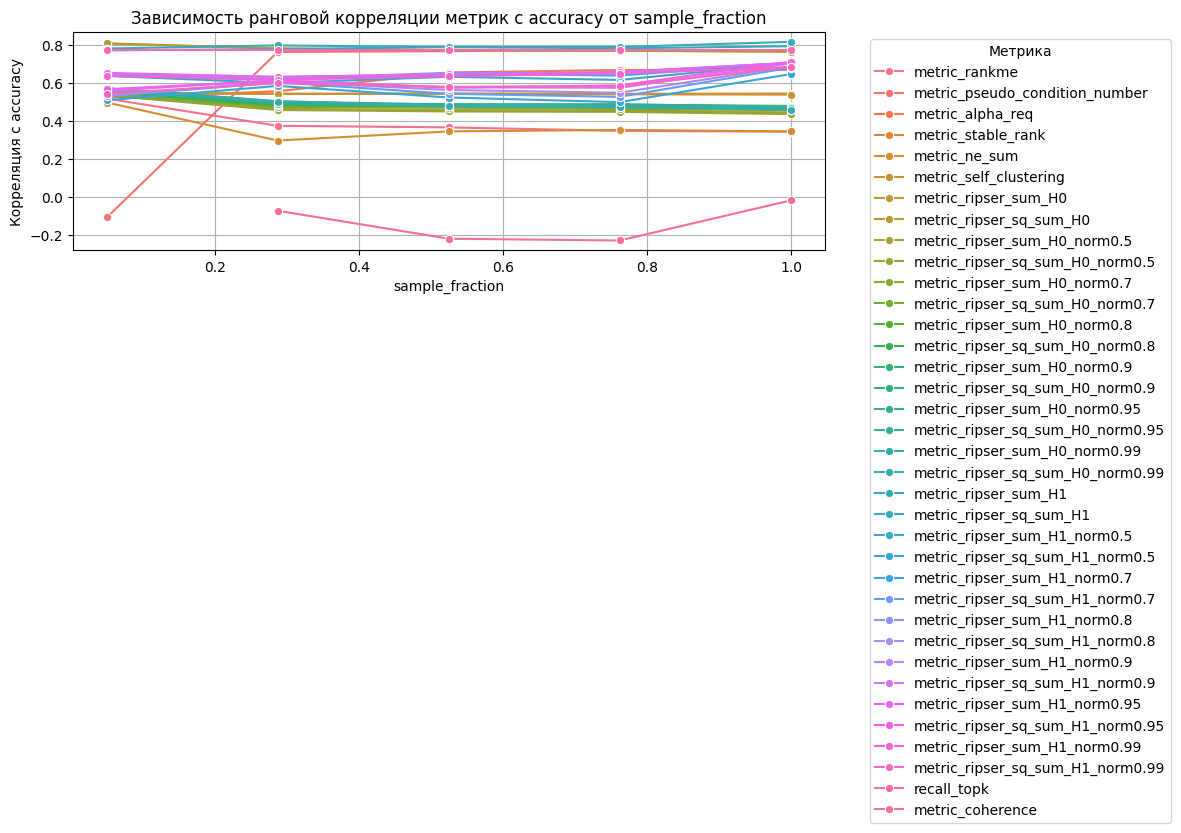

learning_rate


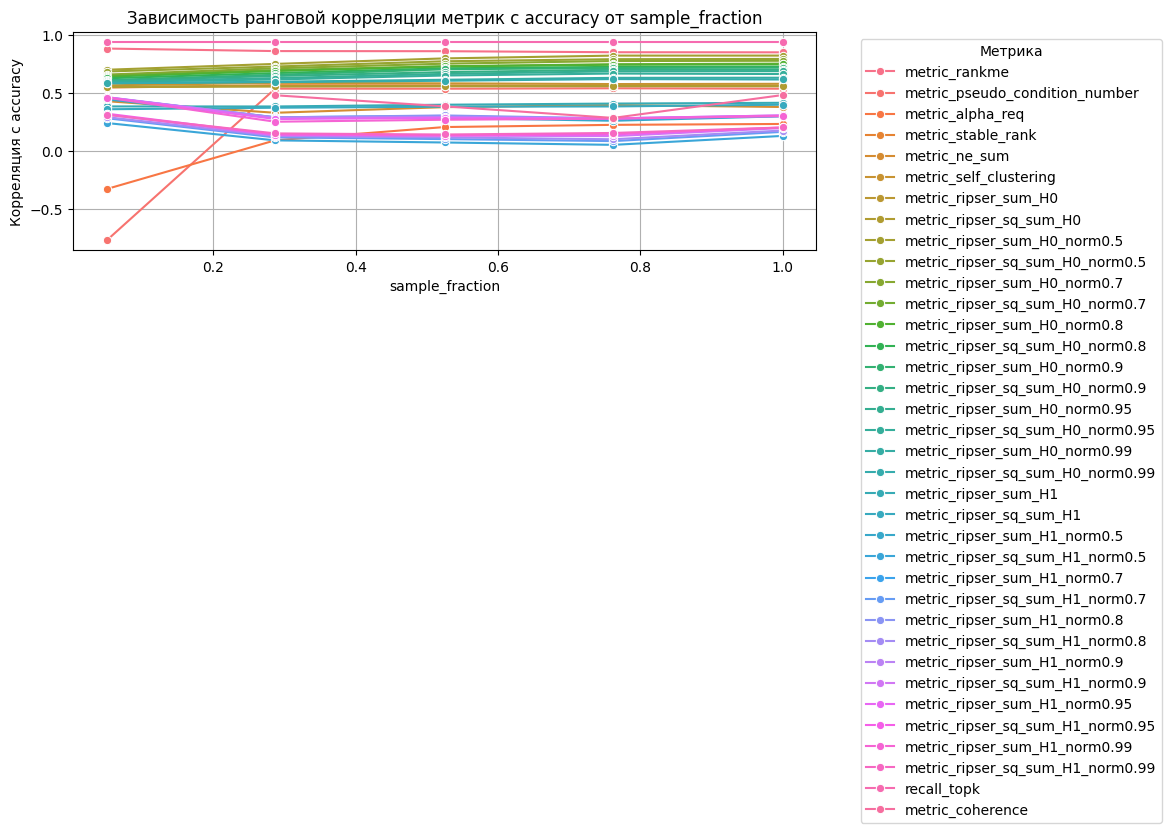

split_count


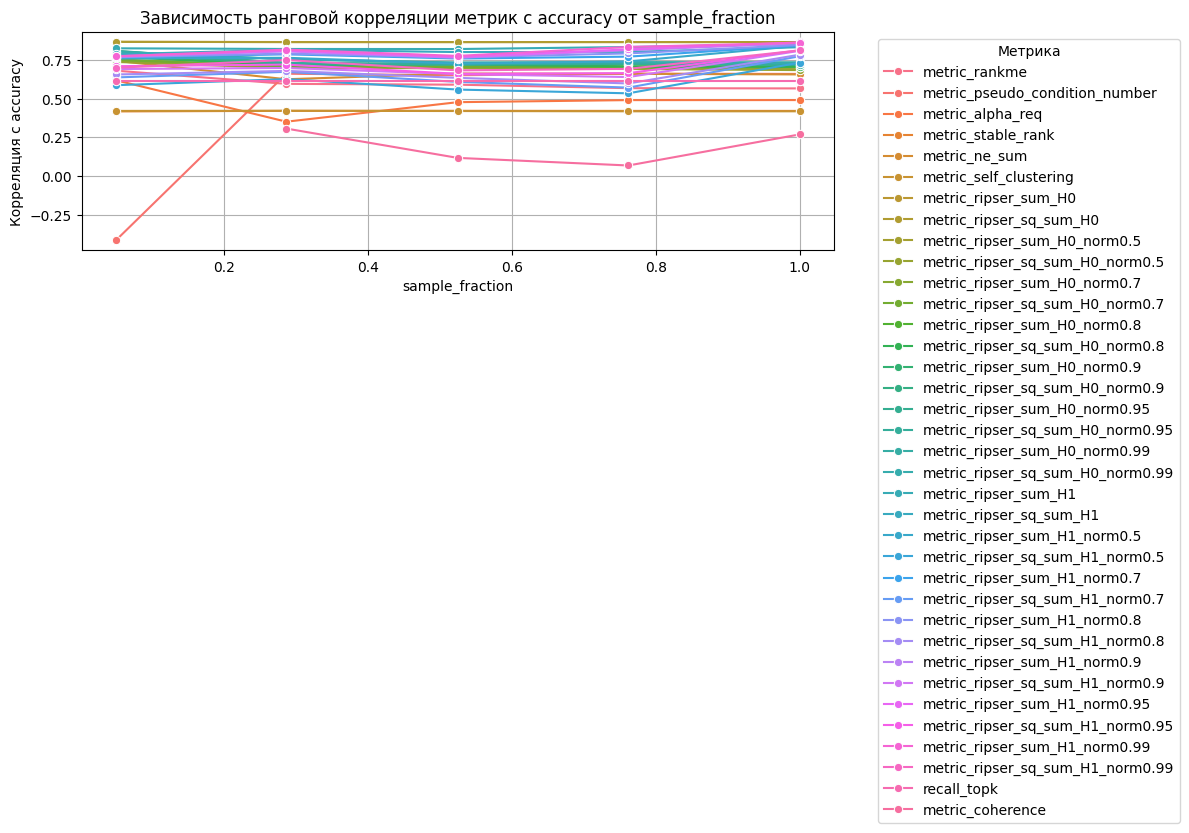

cnt_min


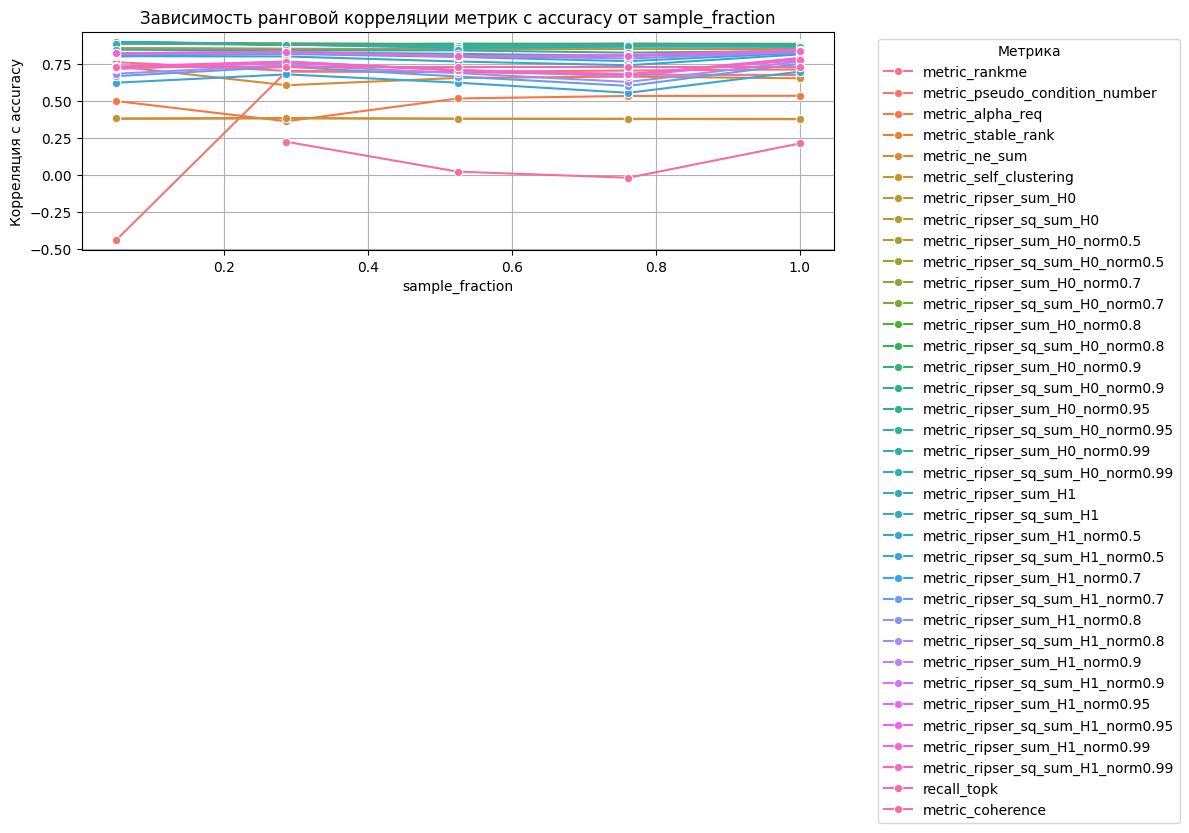

cnt_max


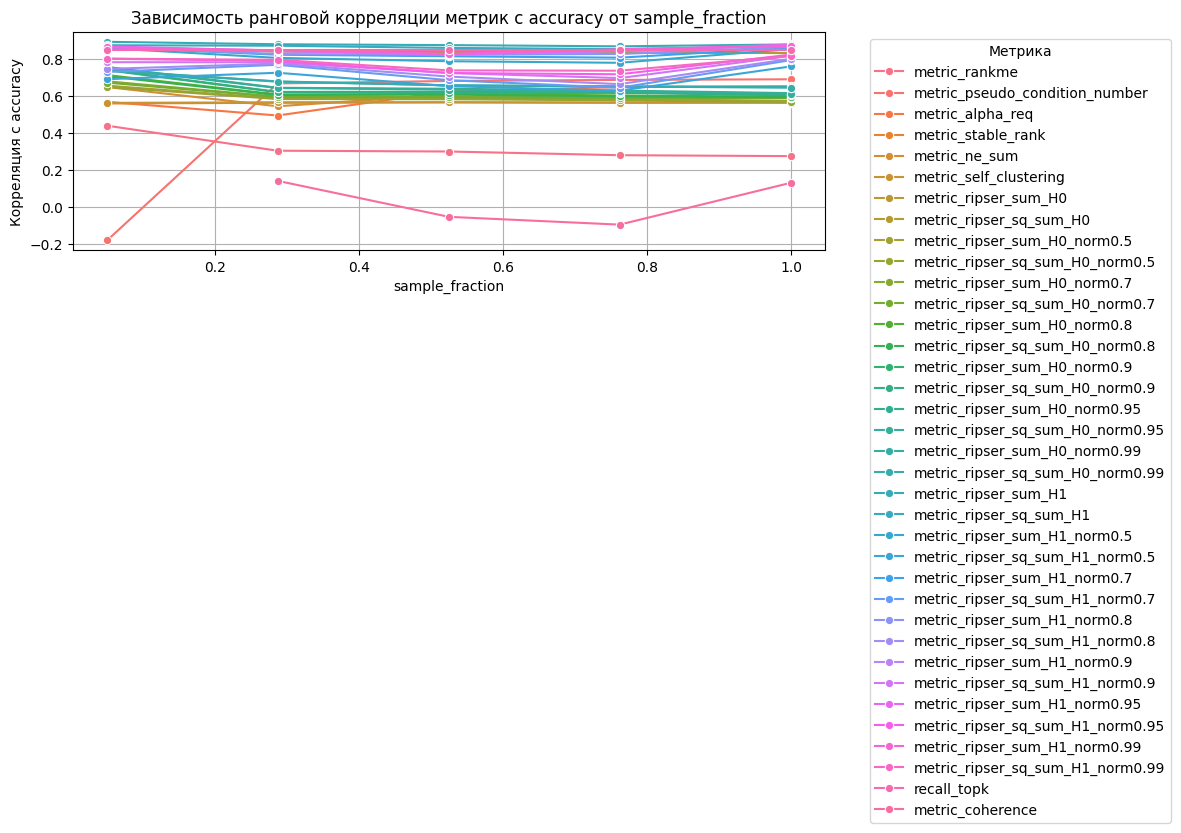

embedding_dim


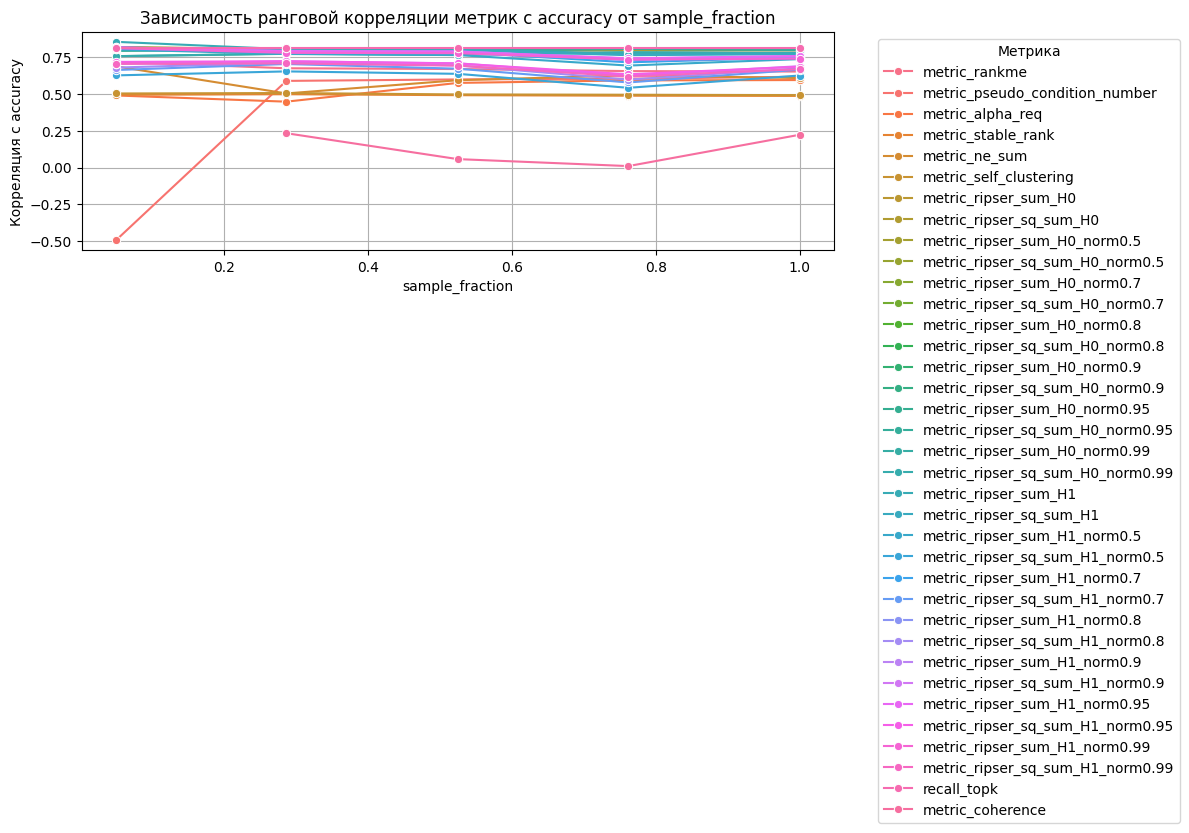

category_embedding_dim


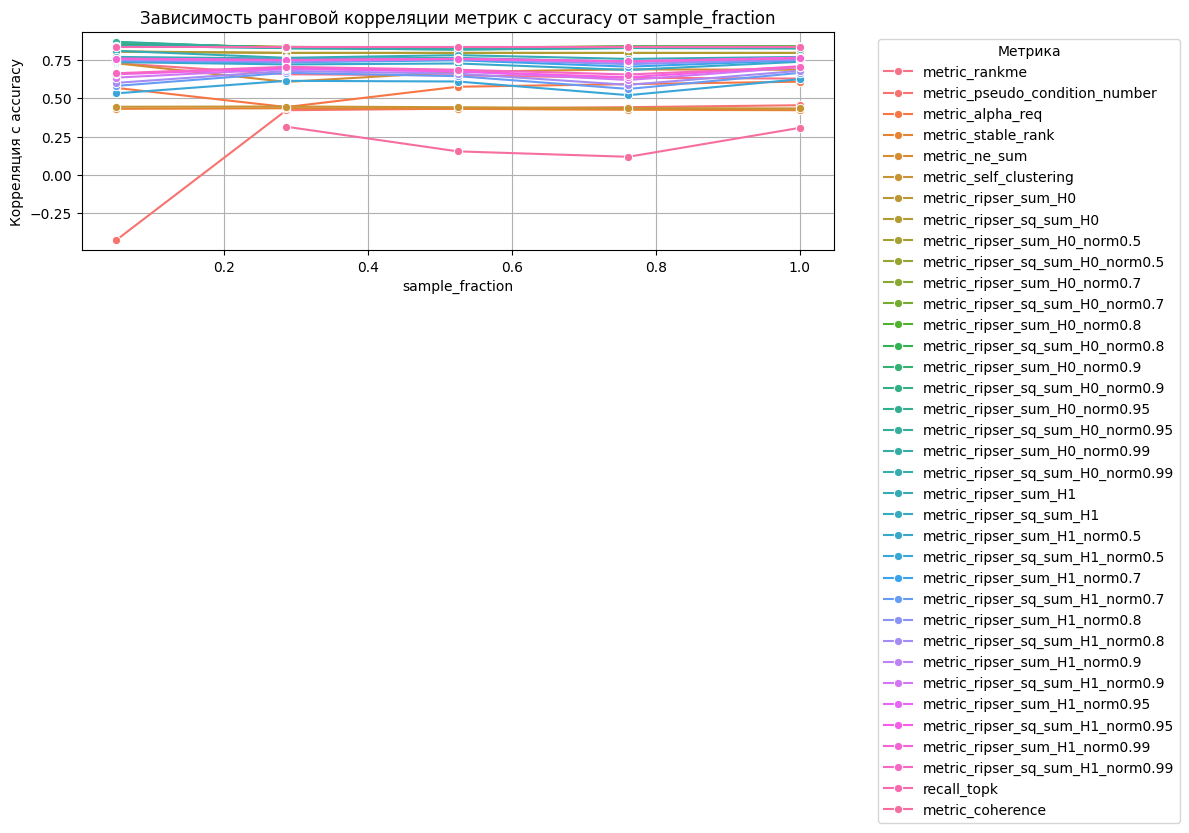

hidden_size


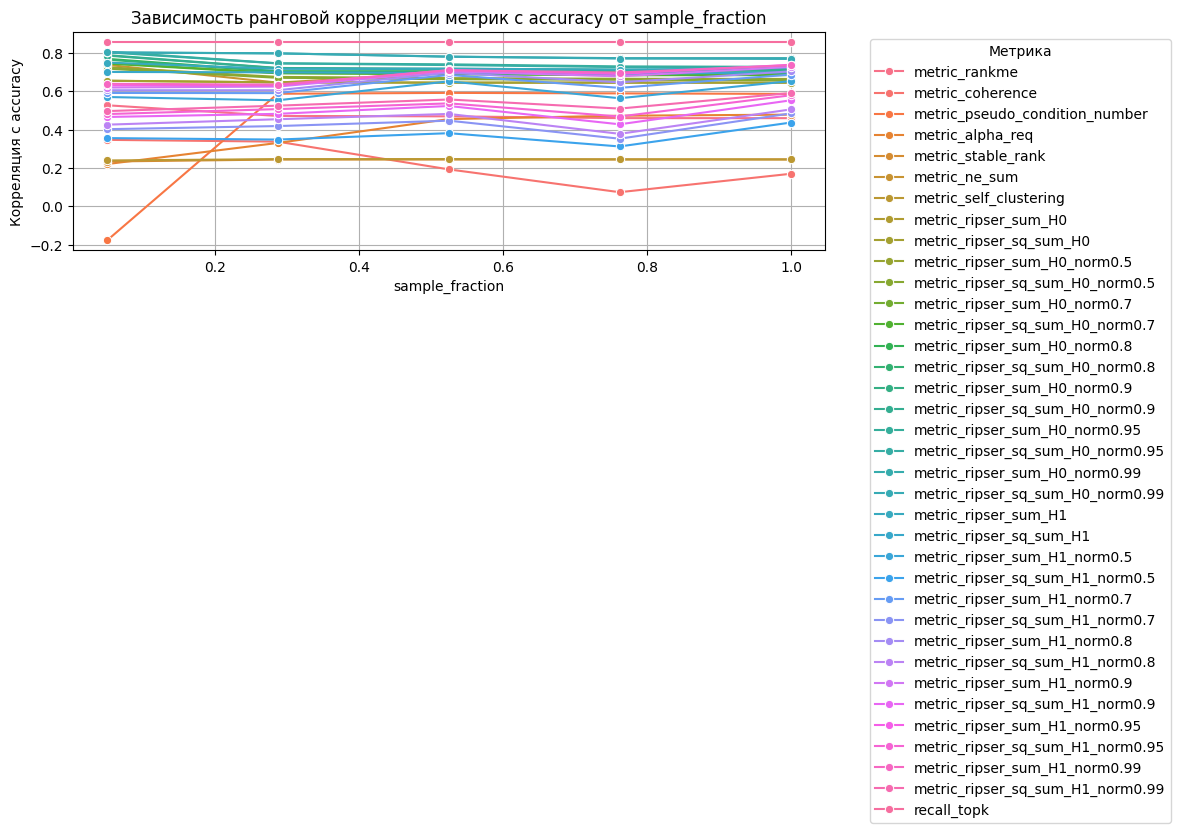

loss


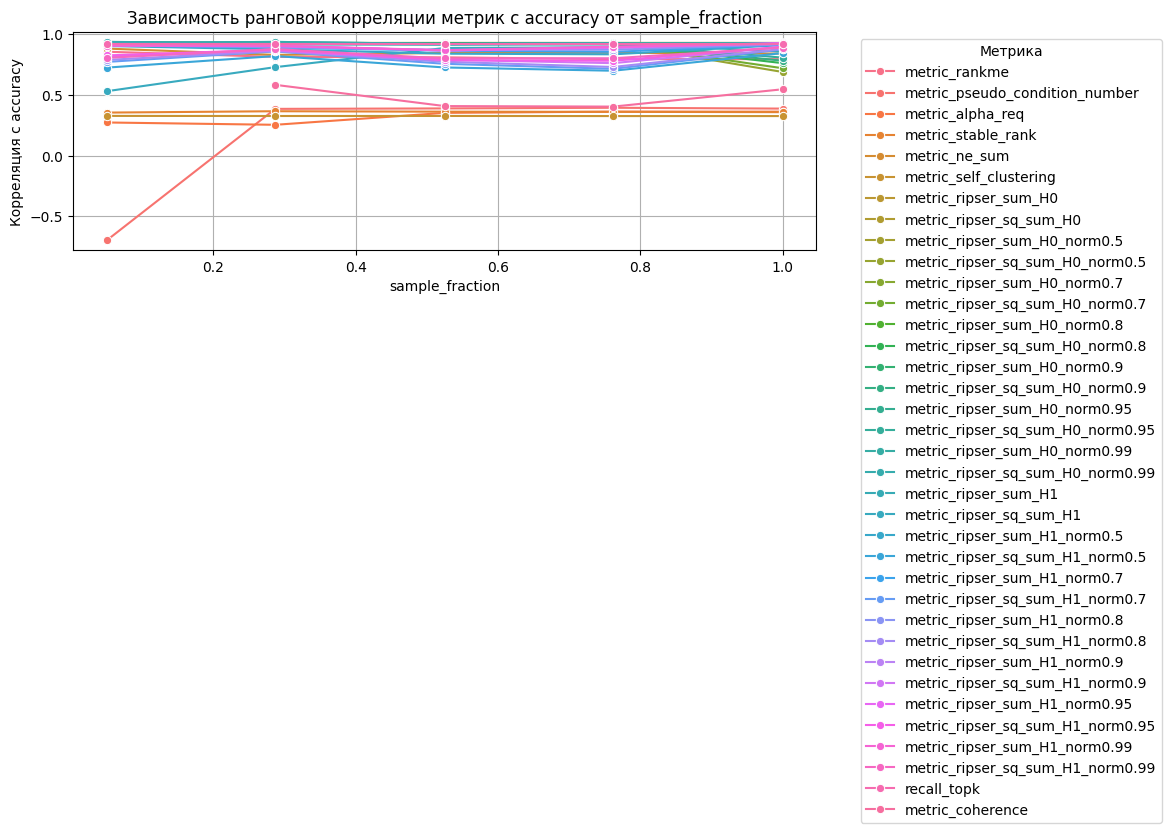

rnn_encoder_type


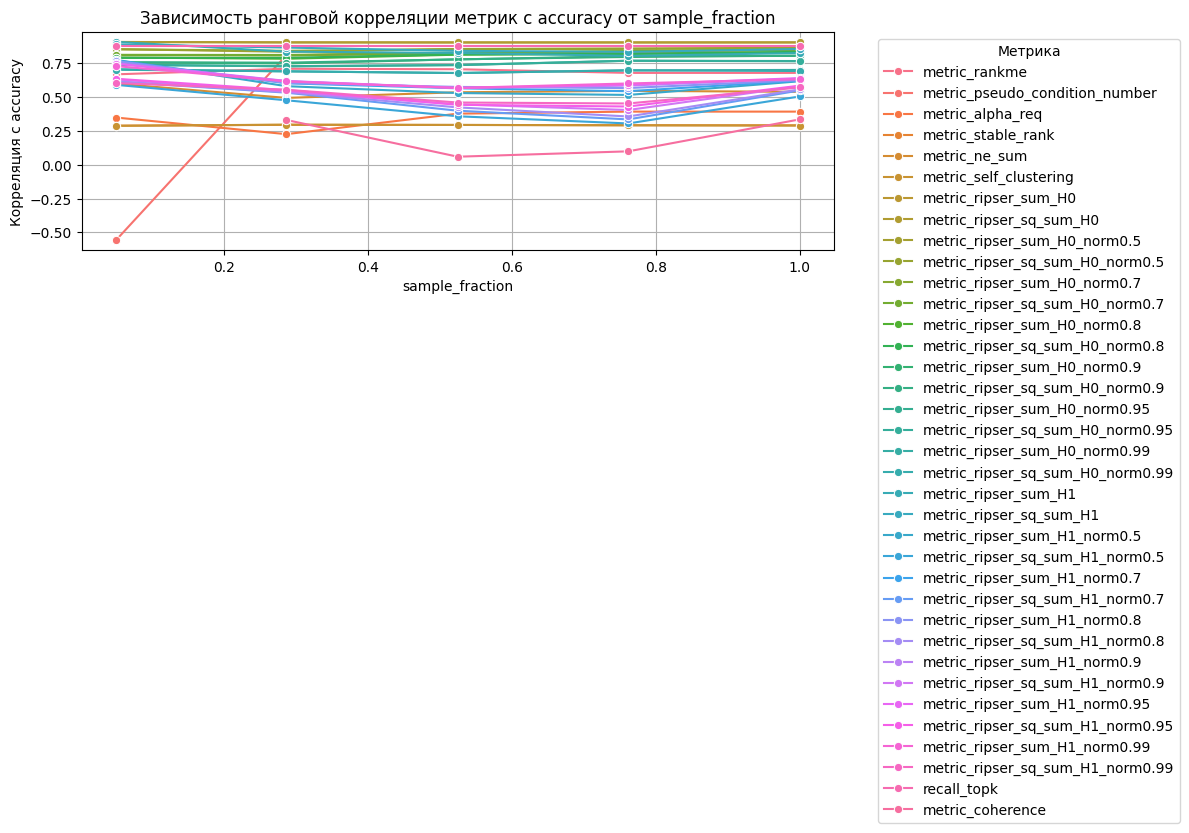

In [41]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [42]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print(corr_df)
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
        print(mean_corr)

batch_size
     sample_fraction                            metric      corr
0               0.05                     metric_rankme  0.519402
1               0.05    metric_pseudo_condition_number -0.107220
2               0.05                  metric_alpha_req  0.524177
3               0.05                metric_stable_rank  0.548455
4               0.05                     metric_ne_sum  0.498736
..               ...                               ...       ...
174             1.00     metric_ripser_sum_H1_norm0.95  0.708685
175             1.00  metric_ripser_sq_sum_H1_norm0.95  0.714353
176             1.00     metric_ripser_sum_H1_norm0.99  0.686234
177             1.00  metric_ripser_sq_sum_H1_norm0.99  0.687259
178             1.00                       recall_topk  0.774009

[179 rows x 3 columns]
metric
metric_ripser_sq_sum_H0             0.798064
metric_ripser_sum_H0                0.796736
metric_ripser_sq_sum_H1             0.792230
metric_ripser_sum_H1                0.77761

# Score of best hyperparams by metric

In [43]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

/tmp/ipykernel_1645991/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1645991/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1645991/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


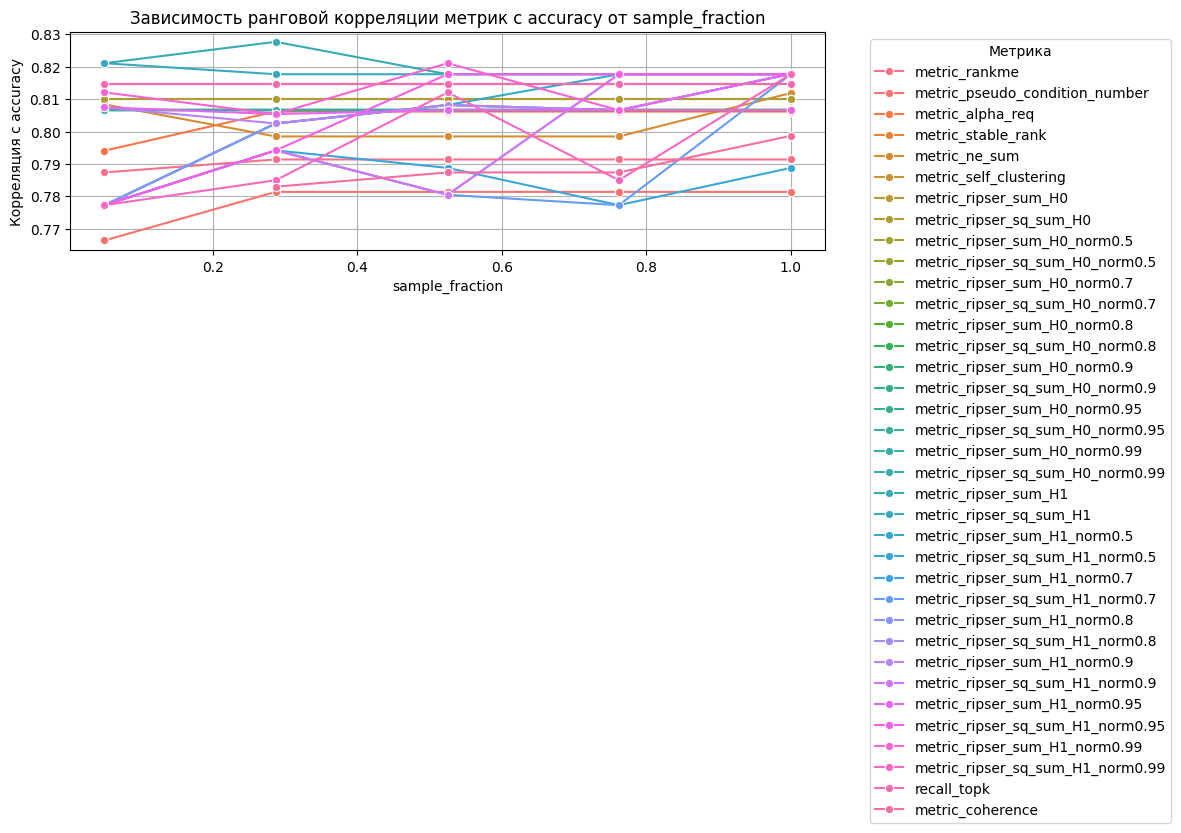

learning_rate


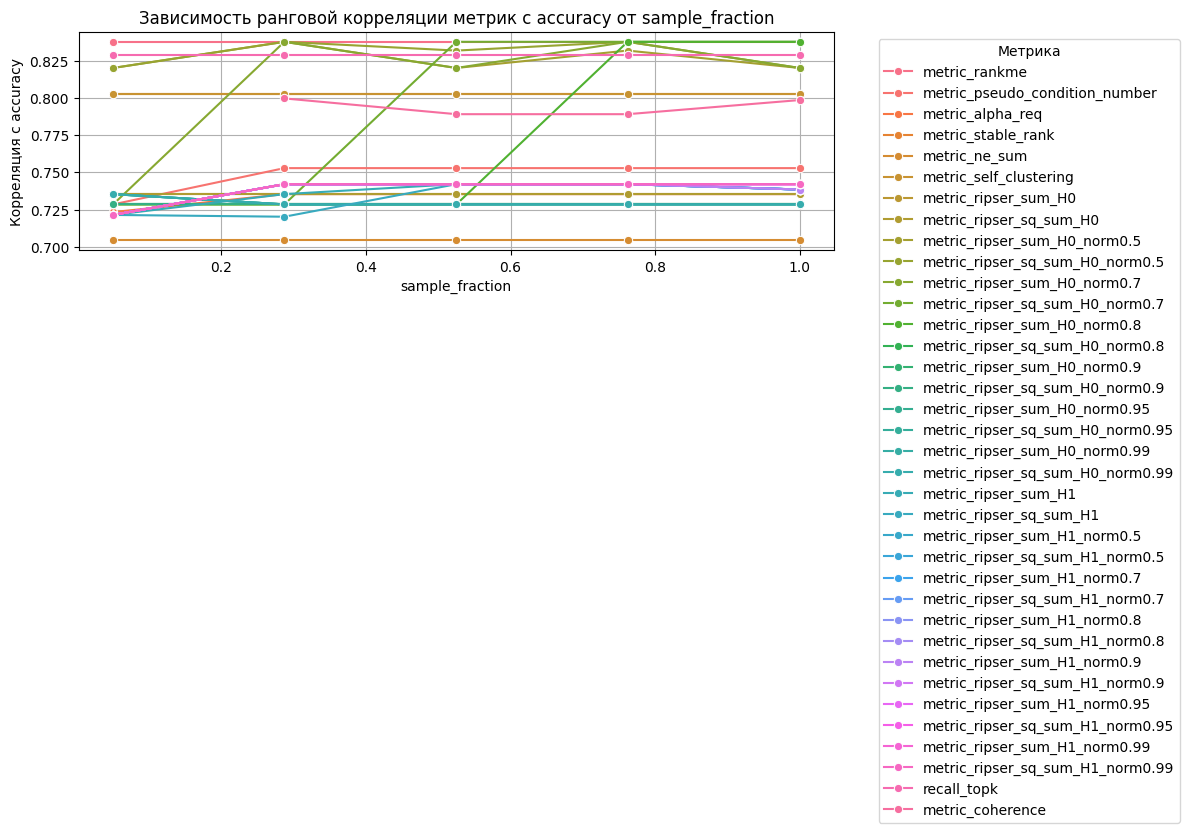

split_count


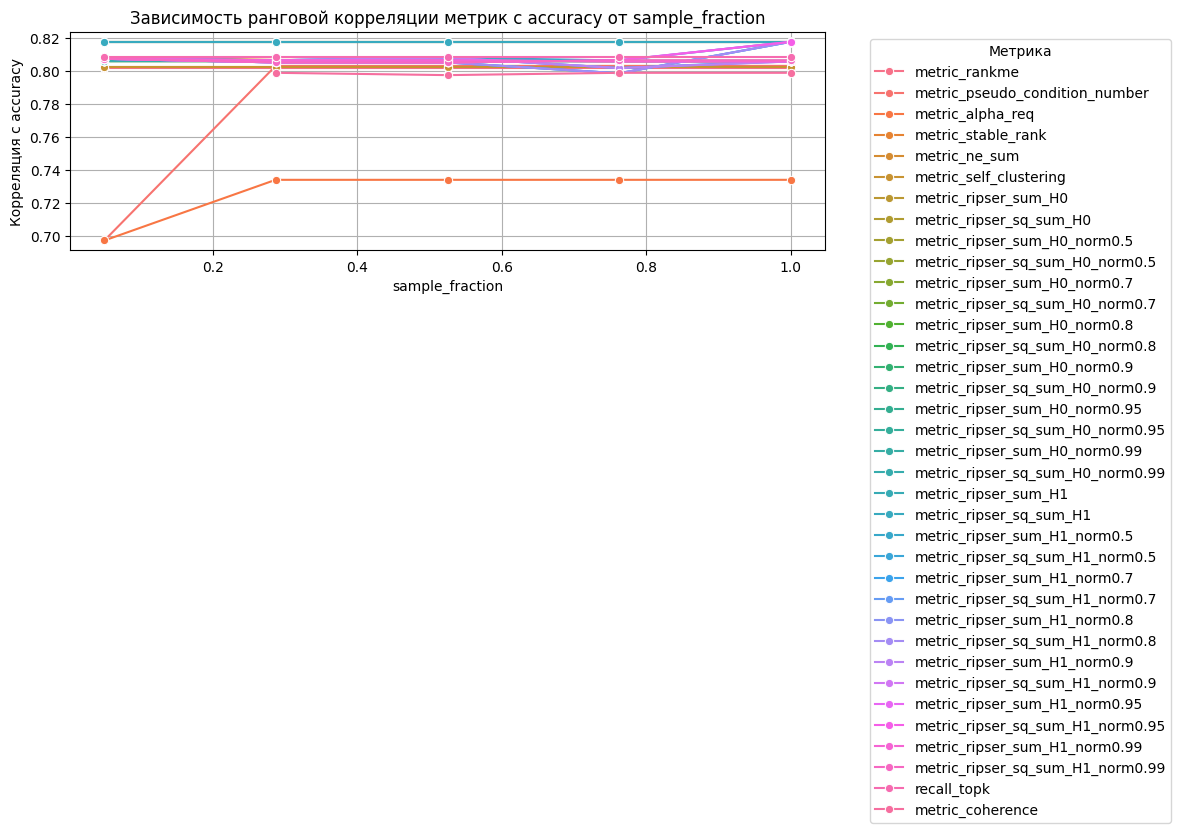

cnt_min


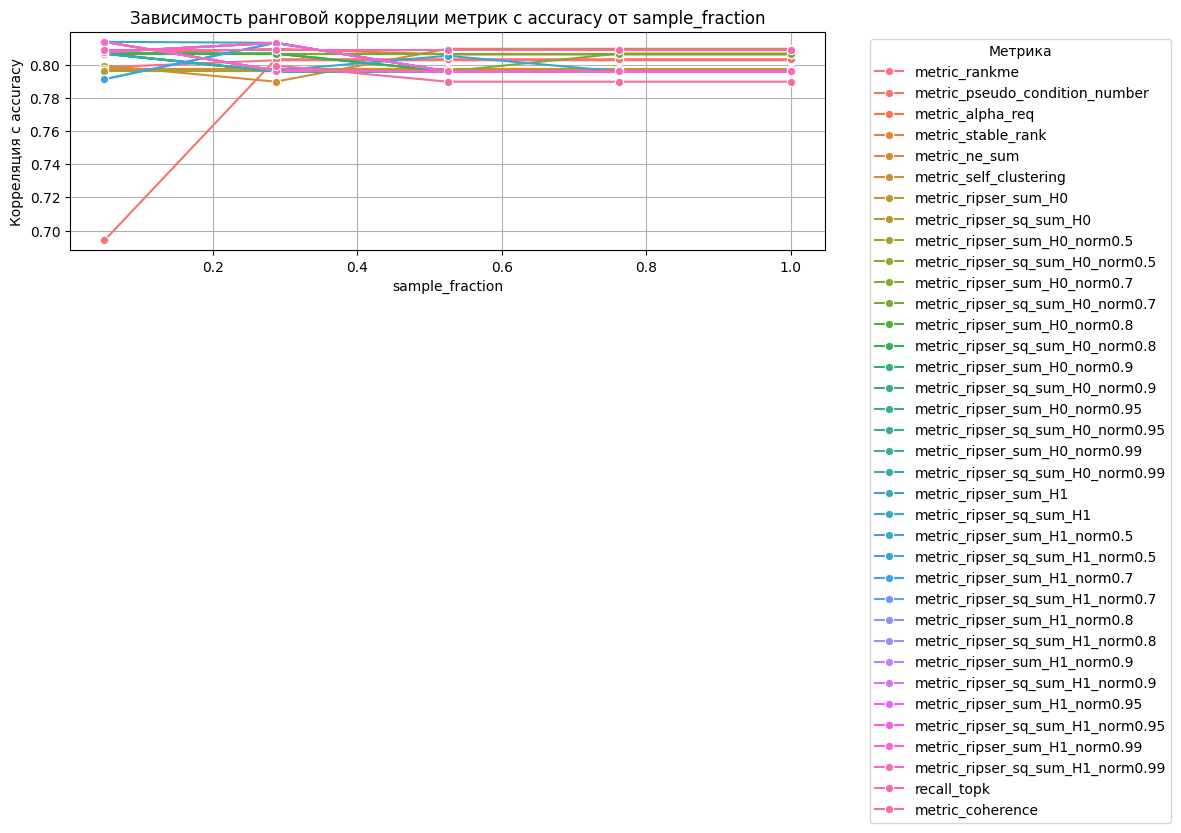

cnt_max


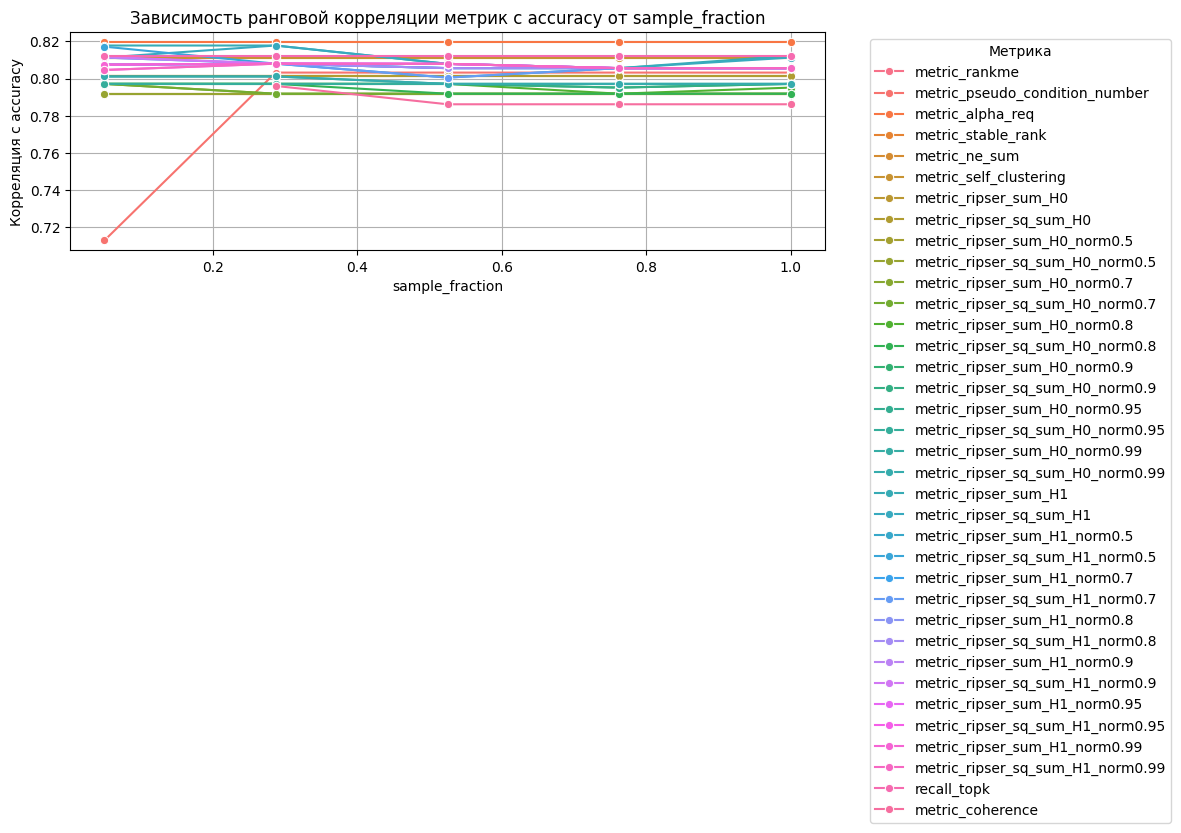

embedding_dim


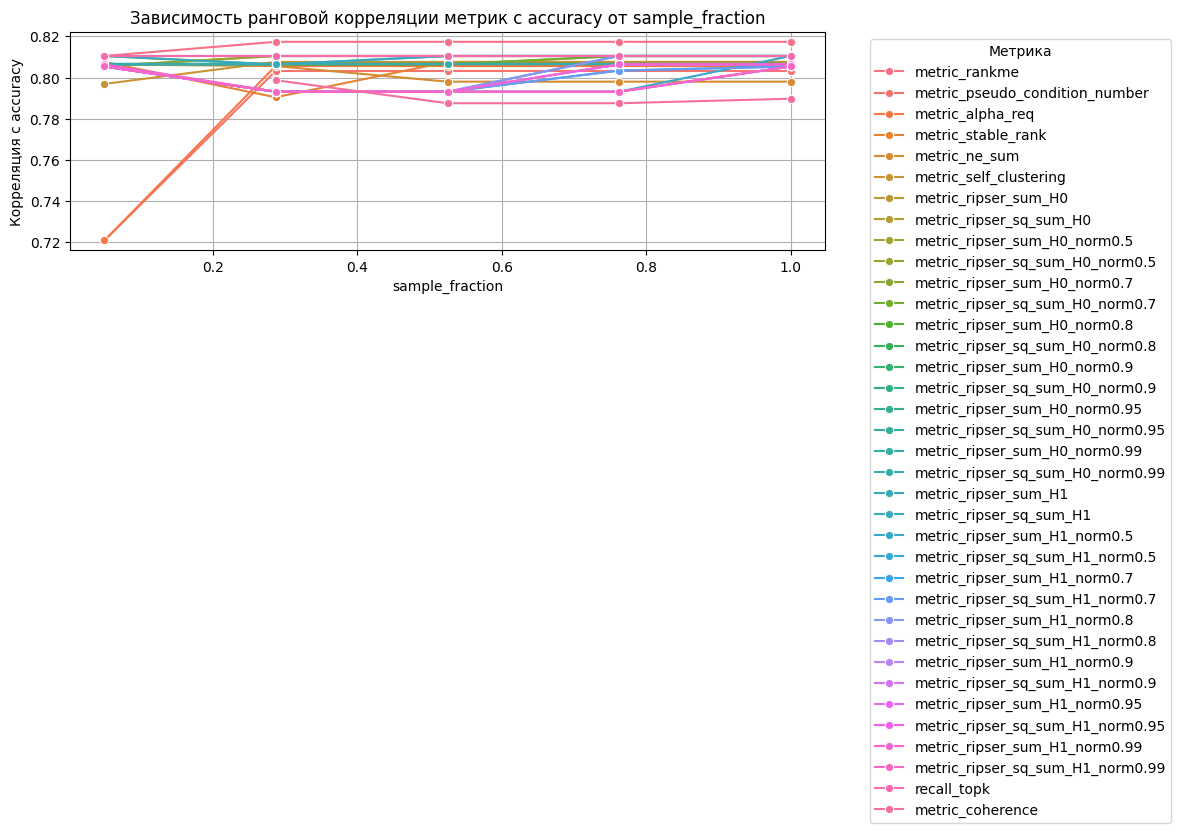

category_embedding_dim


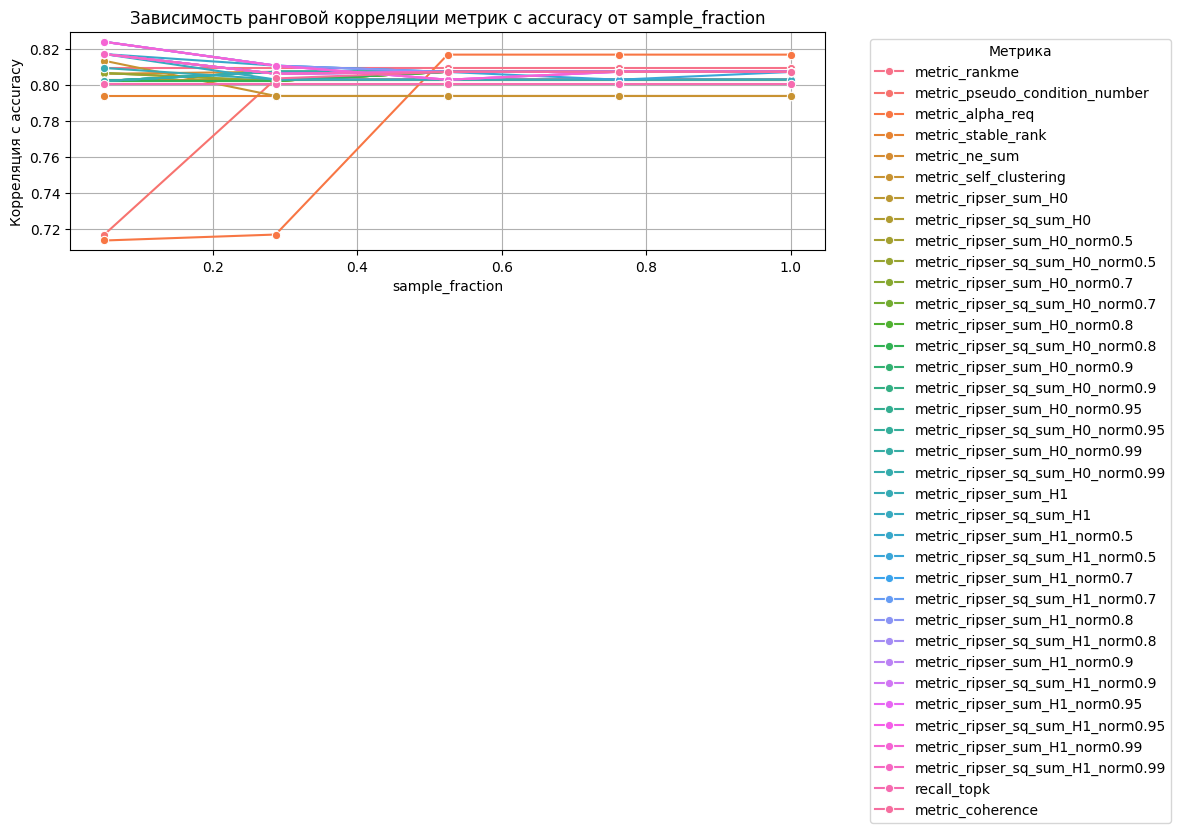

hidden_size


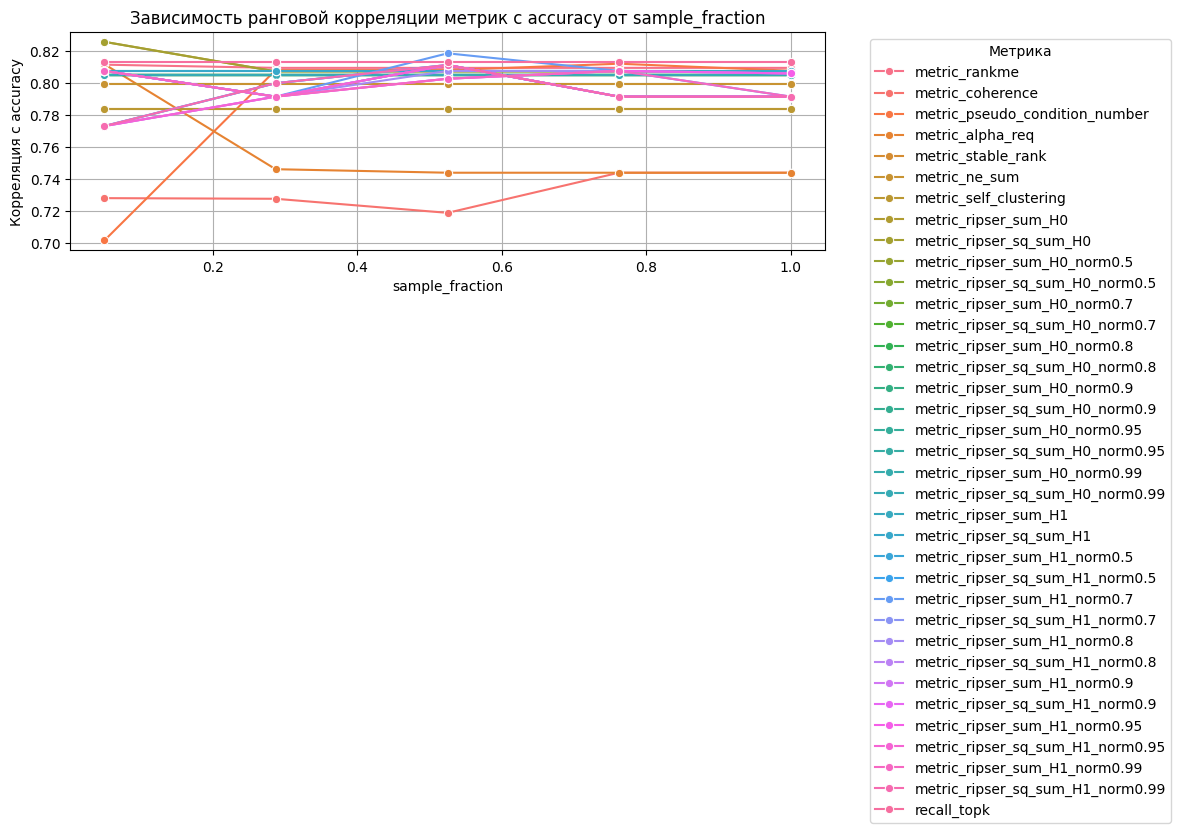

loss


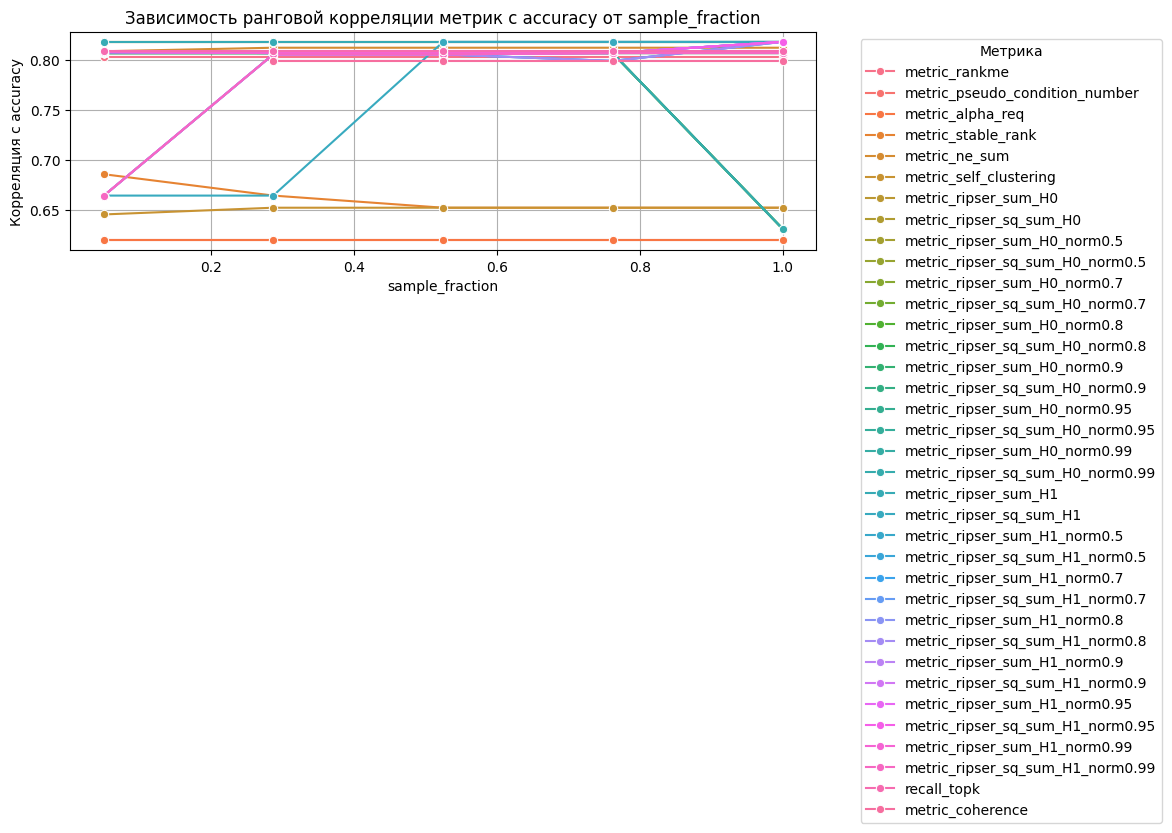

rnn_encoder_type


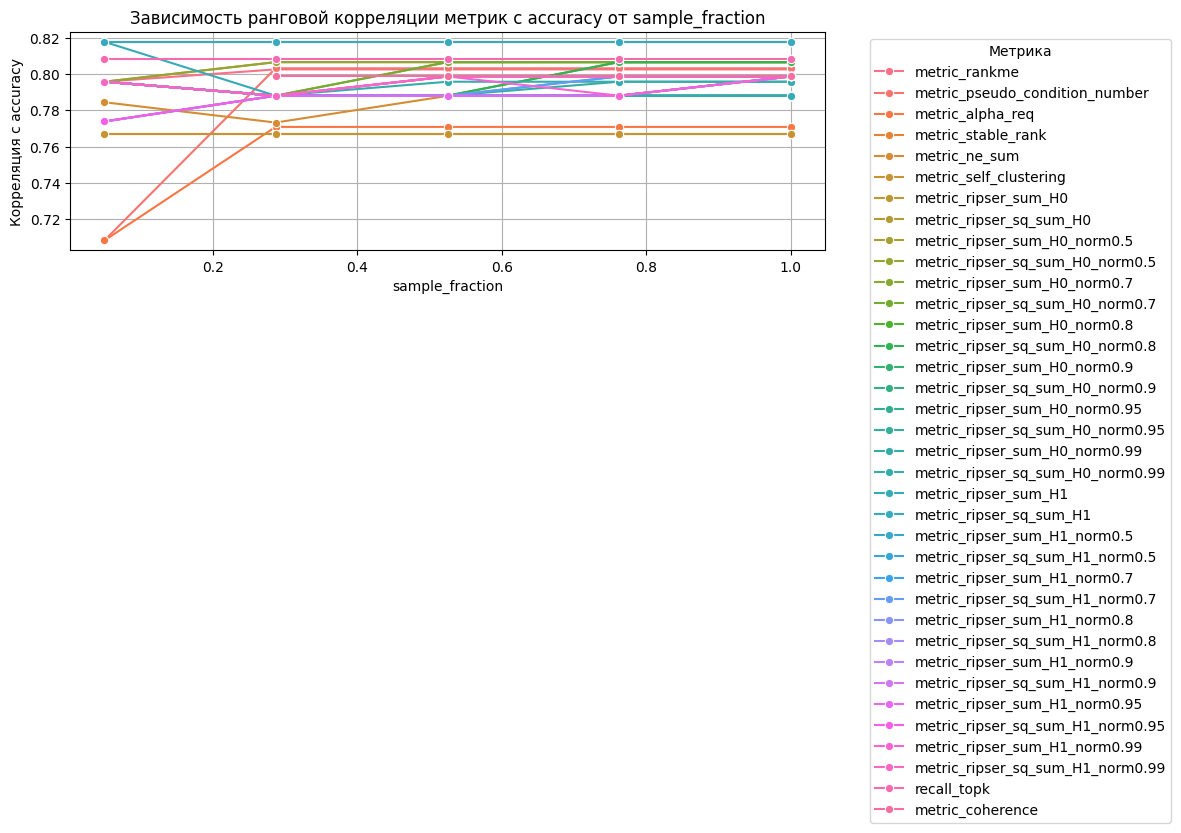

In [44]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [45]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print (corr_df)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.1].groupby("metric")["auc"].mean().sort_values(ascending=False)
    
        print(mean_corr)

batch_size
     sample_fraction                            metric     auc
0               0.05                     metric_rankme  0.7874
1               0.05    metric_pseudo_condition_number  0.7664
2               0.05                  metric_alpha_req  0.7941
3               0.05                metric_stable_rank  0.8146
4               0.05                     metric_ne_sum  0.8084
..               ...                               ...     ...
174             1.00     metric_ripser_sum_H1_norm0.95  0.8178
175             1.00  metric_ripser_sq_sum_H1_norm0.95  0.8177
176             1.00     metric_ripser_sum_H1_norm0.99  0.8066
177             1.00  metric_ripser_sq_sum_H1_norm0.99  0.8177
178             1.00                       recall_topk  0.8146

[179 rows x 3 columns]
metric
metric_ripser_sq_sum_H1             0.8211
metric_ripser_sum_H1                0.8211
metric_self_clustering              0.8146
metric_stable_rank                  0.8146
recall_topk                   

In [46]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)

        print(mean_corr)

batch_size
metric
metric_ripser_sum_H1_norm0.95       0.8178
metric_ripser_sum_H1_norm0.9        0.8178
metric_ripser_sum_H1_norm0.8        0.8178
metric_ripser_sum_H1_norm0.7        0.8178
metric_ripser_sum_H1_norm0.5        0.8178
metric_ripser_sq_sum_H1             0.8177
metric_ripser_sum_H1                0.8177
metric_ripser_sq_sum_H1_norm0.99    0.8177
metric_ripser_sq_sum_H1_norm0.7     0.8177
metric_ripser_sq_sum_H1_norm0.9     0.8177
metric_ripser_sq_sum_H1_norm0.95    0.8177
metric_ripser_sq_sum_H1_norm0.8     0.8177
metric_self_clustering              0.8146
metric_stable_rank                  0.8146
recall_topk                         0.8146
metric_ne_sum                       0.8119
metric_ripser_sum_H0                0.8100
metric_ripser_sq_sum_H0             0.8100
metric_ripser_sq_sum_H0_norm0.7     0.8066
metric_ripser_sum_H0_norm0.99       0.8066
metric_ripser_sum_H0_norm0.7        0.8066
metric_ripser_sum_H0_norm0.5        0.8066
metric_ripser_sum_H0_norm0.95       

In [47]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
        print(param)
        print(mean_corr)

batch_size
metric
metric_ripser_sum_H1                0.820380
metric_ripser_sq_sum_H1             0.818380
recall_topk                         0.814600
metric_self_clustering              0.814600
metric_stable_rank                  0.814600
metric_ripser_sum_H1_norm0.99       0.810360
metric_ripser_sum_H0                0.810000
metric_ripser_sq_sum_H0             0.810000
metric_ripser_sum_H1_norm0.95       0.808780
metric_ripser_sum_H1_norm0.9        0.808520
metric_ripser_sum_H0_norm0.95       0.806600
metric_ripser_sum_H0_norm0.9        0.806600
metric_ripser_sum_H0_norm0.7        0.806600
metric_ripser_sum_H0_norm0.99       0.806600
metric_ripser_sq_sum_H0_norm0.99    0.806600
metric_ripser_sq_sum_H0_norm0.5     0.806600
metric_ripser_sq_sum_H0_norm0.95    0.806600
metric_ripser_sq_sum_H0_norm0.9     0.806600
metric_ripser_sq_sum_H0_norm0.7     0.806600
metric_ripser_sq_sum_H0_norm0.8     0.806600
metric_ripser_sum_H0_norm0.8        0.806600
metric_ripser_sum_H0_norm0.5        0

In [48]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H1                0.820380
metric_ripser_sq_sum_H1             0.818380
recall_topk                         0.814600
metric_self_clustering              0.814600
metric_stable_rank                  0.814600
metric_ripser_sum_H1_norm0.99       0.810360
metric_ripser_sum_H0                0.810000
metric_ripser_sq_sum_H0             0.810000
metric_ripser_sum_H1_norm0.95       0.808780
metric_ripser_sum_H1_norm0.9        0.808520
metric_ripser_sum_H0_norm0.95       0.806600
metric_ripser_sum_H0_norm0.9        0.806600
metric_ripser_sum_H0_norm0.7        0.806600
metric_ripser_sum_H0_norm0.99       0.806600
metric_ripser_sq_sum_H0_norm0.99    0.806600
metric_ripser_sq_sum_H0_norm0.5     0.806600
metric_ripser_sq_sum_H0_norm0.95    0.806600
metric_ripser_sq_sum_H0_norm0.9     0.806600
metric_ripser_sq_sum_H0_norm0.7     0.806600
metric_ripser_sq_sum_H0_norm0.8     0.806600
metric_ripser_sum_H0_norm0.8        0.806600
metric_ripser_sum_H0_norm0.5        0

# Standard deviation of score of best param selection

In [49]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


batch_size


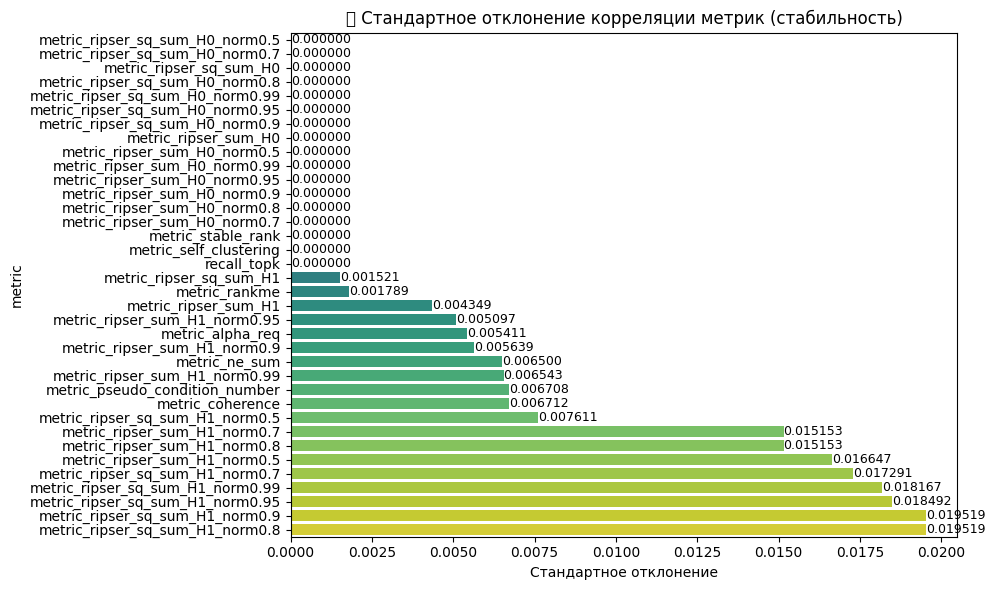

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


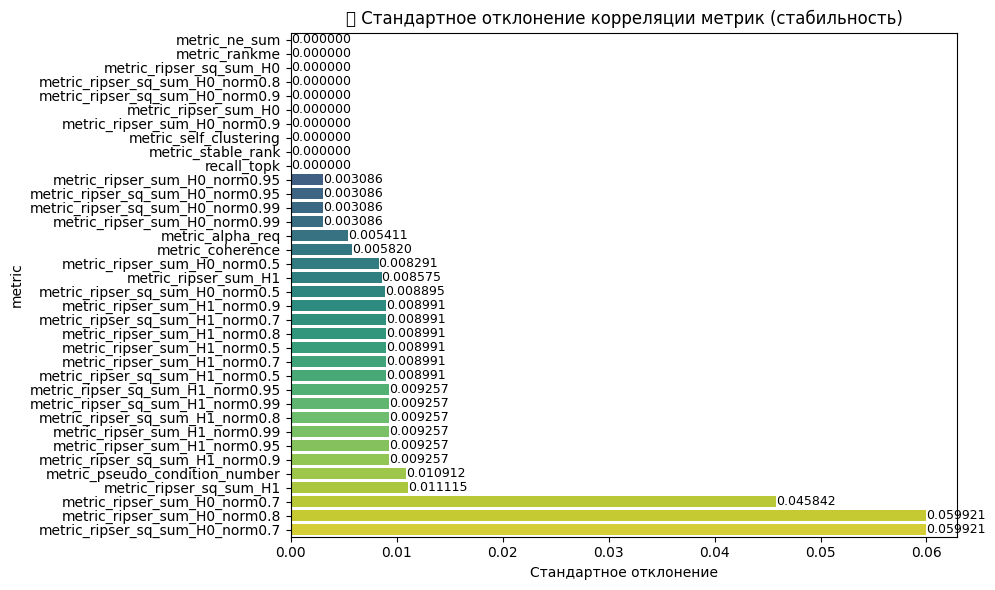

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


split_count


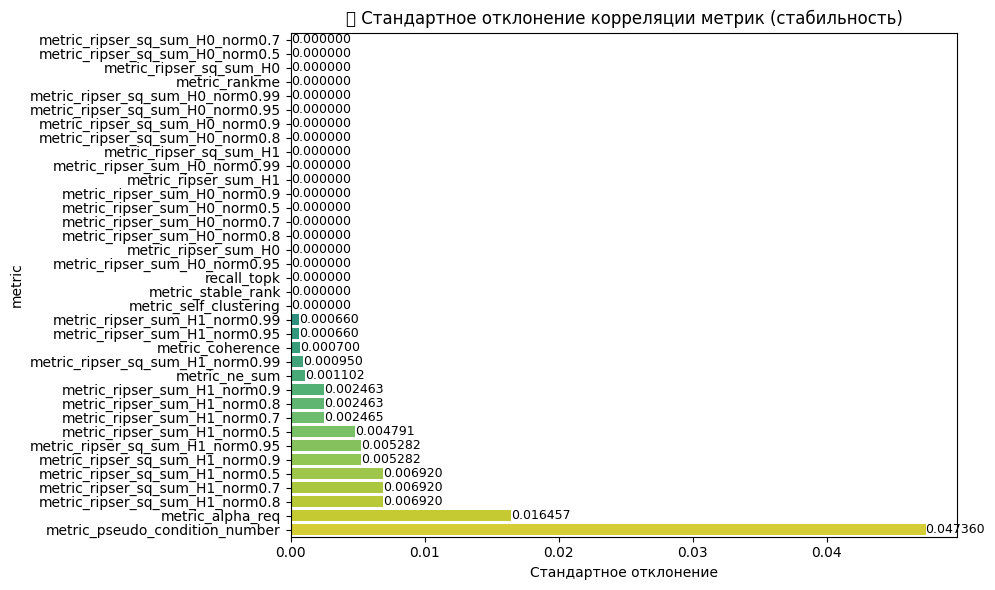

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


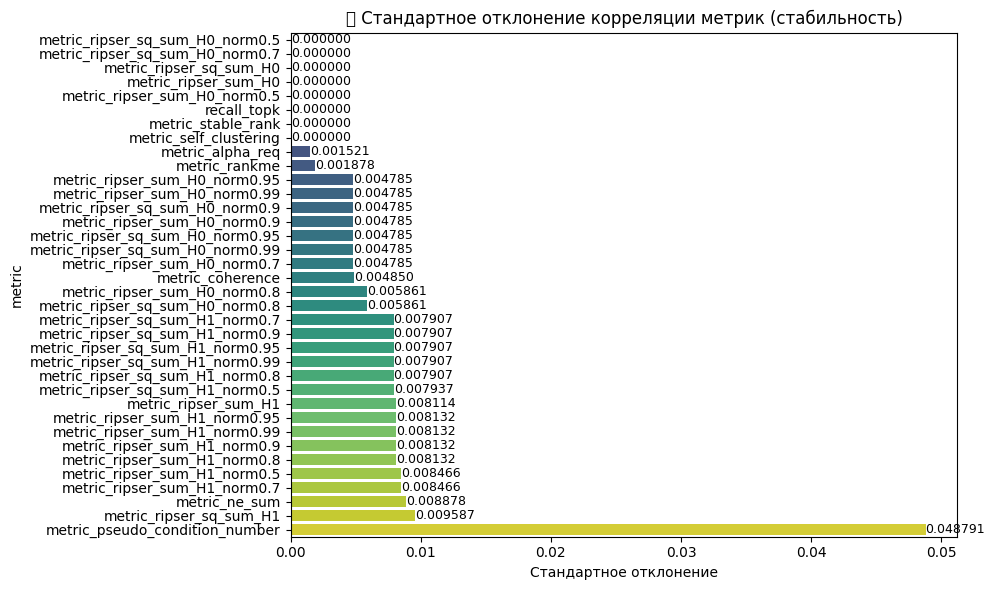

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


cnt_max


/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


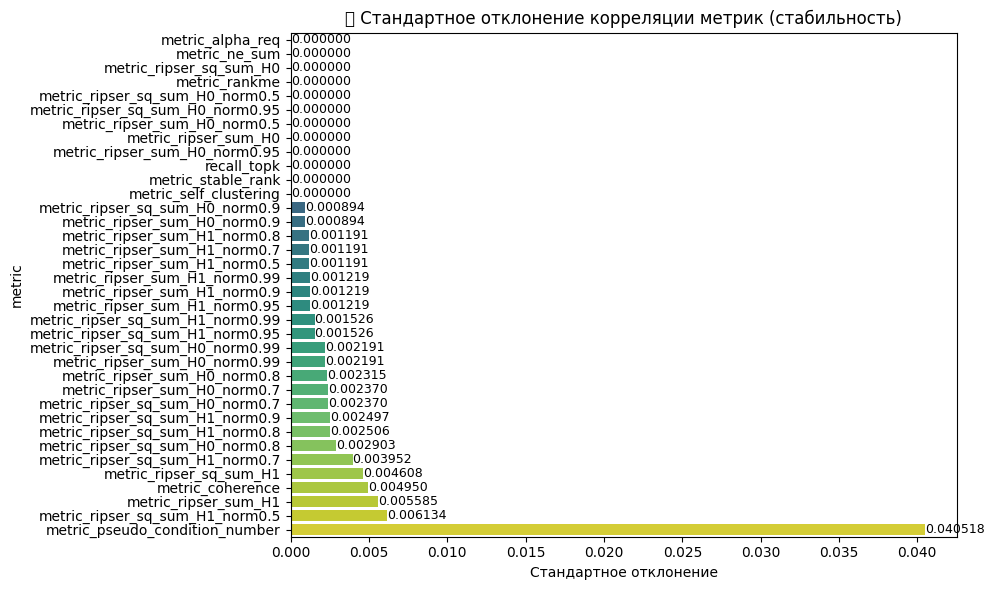

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


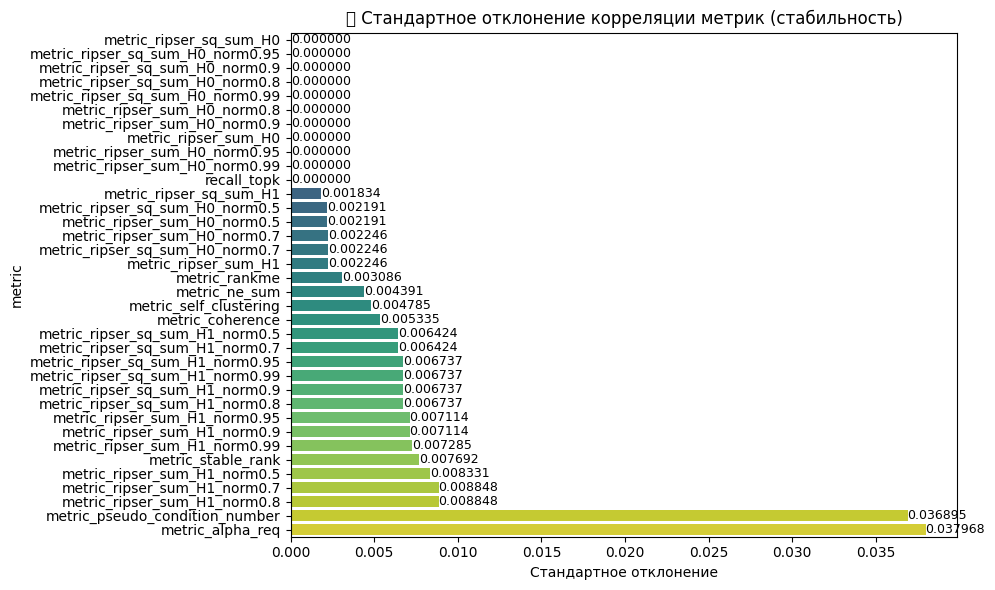

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


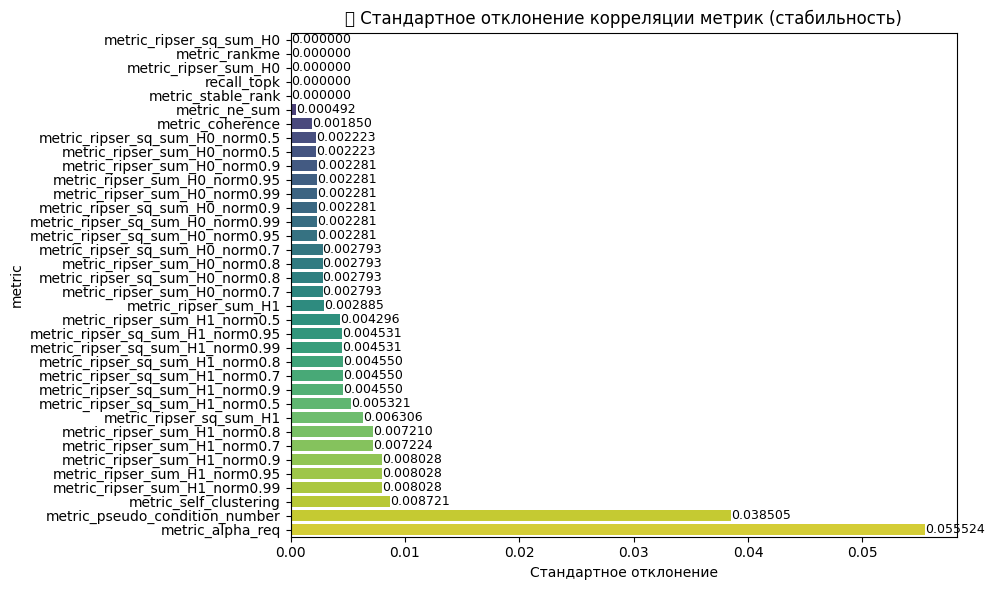

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


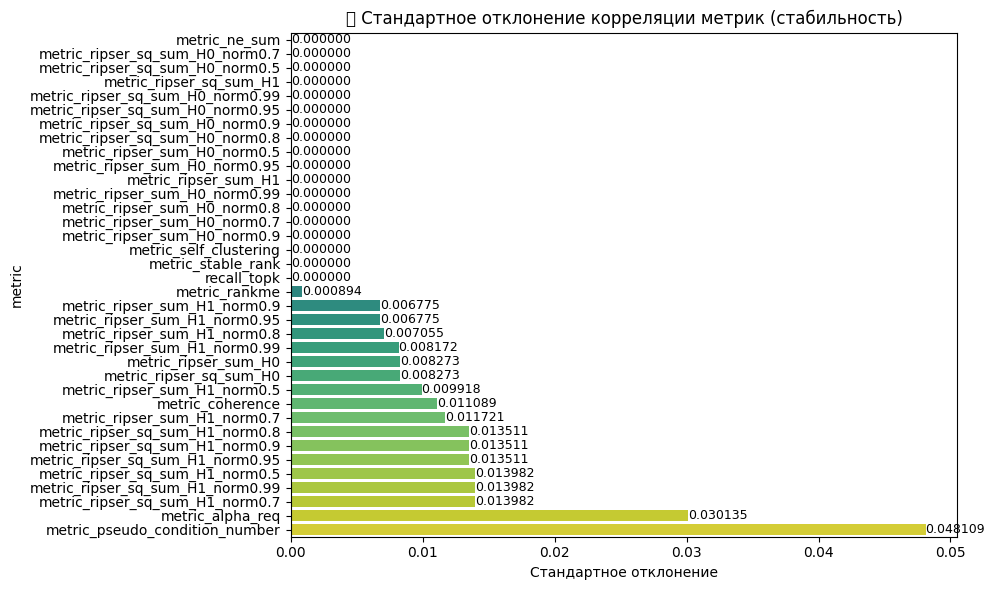

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


loss


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


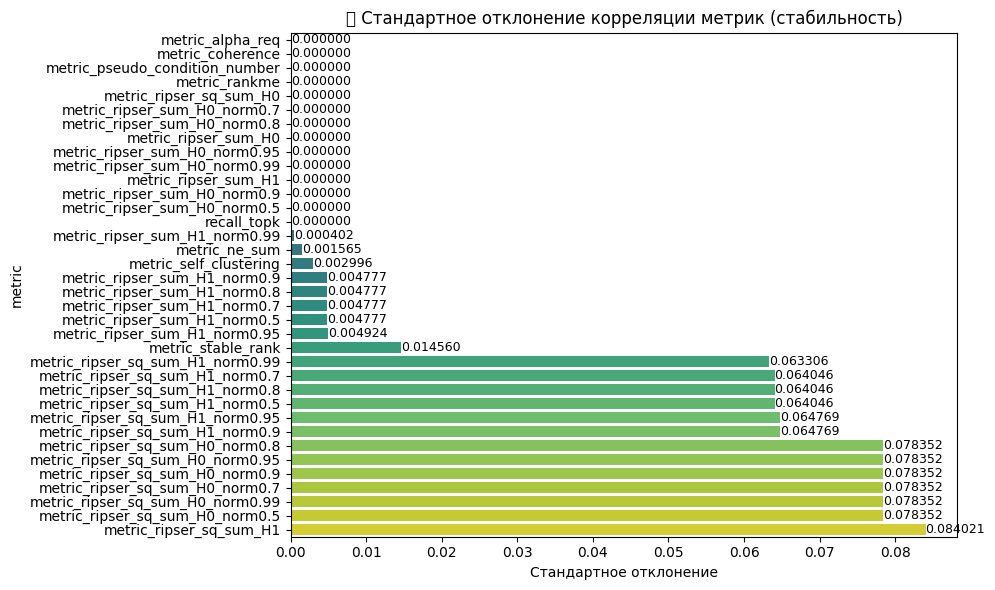

/tmp/ipykernel_1645991/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1645991/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


rnn_encoder_type


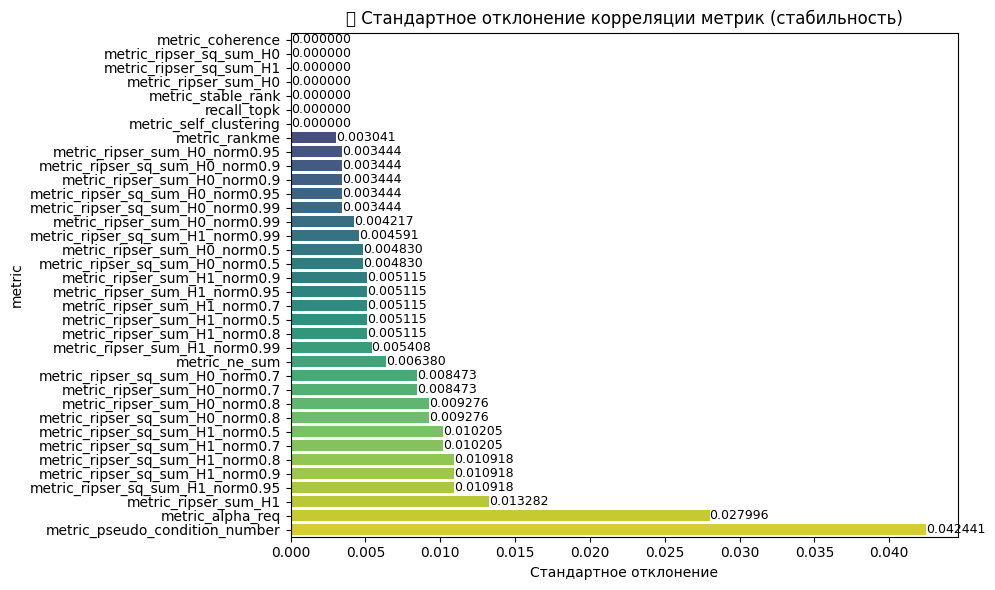

In [50]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()